In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
from concept_abstraction.plotting import *
from concept_abstraction.utils import *
import matplotlib.lines as mlines
from concept_abstraction.concept_bank import get_all_mini_grid_names

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [3]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [4]:
style_size = 'paper'

## New Plots

In [5]:
training_times = {
    'cart_pole': 4_000_000,
    'mini_grid': 500_000,
    'glucose': 4_000_000,
    'pong': 15_000_000,
    'boxing': 15_000_000,
}

gold_timesteps = {
    'cart_pole': 4_000_000,
    'mini_grid': 1_000_000,
    'glucose': 4_000_000,
    'pong': 15_000_000,
    'boxing': 30_000_000,
}

name_to_nice = {
    'cart_pole': "CartPole",
    'mini_grid': "MiniGrid",
    'glucose': 'Glucose',
    'pong': "Pong",
    'boxing': "Boxing"
}

methods_to_nice = {
    'random': 'Random',
    'entropy': 'Variance',
    'greedy': 'Greedy',
    'lp_hybrid': "DRS",
    'multiple_log': 'DRS-Log'
}

methods_dict = {
    0: 'Random',
    1: 'Variance',
    2: 'Greedy',
    3: 'DRS',
    4: 'DRS-Log'   
}

num_concepts_selected = {
    'cart_pole': 3,
    'mini_grid': 11, 
    'pong': 57,
    'boxing': 48,
    'glucose': 10
}

method_scales = [lambda d: d/500*100, lambda d: d/1*100, lambda d: (d+21)/42*100, lambda d: d/100*100, lambda d: (d+20)/(40+20)*100]
method_scales_std = [lambda d: d/500*100, lambda d: d/1*100, lambda d: (d)/42*100, lambda d: d/100*100, lambda d: (d)/(40+20)*100]

In [6]:
two_stage = []
basic_comparison = []
perfect_environments = ['cart_pole',"mini_grid","pong","boxing","glucose"]
perfect_methods = ["perfect_concepts","random","entropy","greedy","lp_hybrid"]

imperfect_environments = ['cart_pole',"mini_grid","pong","boxing"]
imperfect_methods = ["imperfect_concepts","random","entropy","greedy","lp_hybrid","multiple_log"]

all_performances_perfect = []
all_performances_perfect_std = []

all_performances_imperfect = []
all_performances_imperfect_std = []

all_baselines = []

for j,e in enumerate(perfect_environments):
    temp = []
    temp_std = []
    for m in perfect_methods:
        matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                    'num_concepts_selected': num_concepts_selected[e],'experiment': 'perfect_comparison',
                                                                    'method': m, 'gold_timesteps': gold_timesteps[e]})
        print("Perfect",e,m,len(matching_params),[(i[m]['reward'],i['parameters']['seed'],i[m]['concepts']) for i in matching_params if m in i])

        performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
        temp.append(performance)

        performance = method_scales_std[j](np.std([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))/len(matching_params)**.5
        temp_std.append(performance)
    all_performances_perfect.append(temp)
    all_performances_perfect_std.append(temp_std)

for j,e in enumerate(imperfect_environments):
    temp = []
    temp_std = []
    for m in imperfect_methods:
        matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                    'num_concepts_selected': num_concepts_selected[e],'experiment': 'imperfect_comparison',
                                                                    'method': m, 'gold_timesteps': gold_timesteps[e]})
        
        print("Imperfect",e,m,len(matching_params),[(i[m]['reward'],i['parameters']['seed'],i[m]['concepts']) for i in matching_params if m in i])
        performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
        temp.append(performance)

        performance = method_scales_std[j](np.std([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))/len(matching_params)**.5
        temp_std.append(performance)

        if m == 'multiple_log':
            print("Environment",e,[i['concept_accuracy'] for i in matching_params])

    all_performances_imperfect.append(temp)
    all_performances_imperfect_std.append(temp_std)

for j,e in enumerate(perfect_environments):
    matching_params = get_results_matching_parameters("training","",{'environment_string': e,'gold_timesteps': gold_timesteps[e],
                                                                    'experiment': 'training'})
    m = 'ground_truth'
    print("Imperfect",e,m,len(matching_params),[(i[m]['reward'],i['parameters']['seed']) for i in matching_params if m in i])
    performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
    all_baselines.append(performance)

Perfect cart_pole perfect_concepts 6 [(500.0, 45, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]), (499.655, 47, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]), (499.915, 43, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]), (499.5, 42, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]), (500.0, 46, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]), (499.875, 44, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])]
Perfect cart_pole random 6 [(172.8411867364747, 43, [0, 9, 10]), (174.26186291739896, 45, [0, 9, 10]), (173.9106830122592, 44, [0, 9, 10]), (172.74434782608697, 46, [0, 9, 10]), (171.32413793103447, 42, [0, 9, 10]), (173.65034965034965, 47, [0, 9, 10])]
Perfect cart_pole entropy 6 [(122.23645320197045, 43, [4, 9, 3]), (122.98019801980197, 44, [4, 3, 9]), (126.8764331210191, 47, [10, 3, 4]), (325.8973509933775, 46, [10, 3, 9]), (117.70567375886525, 45, [3, 4, 10]), (286.7325581395349, 42, [10, 9, 3])]
Perfect cart_pole greedy 6 [(326.2119205298013, 44, [10, 3, 9]), (167.77871621621622, 46, [10, 9, 0]), (110.20066518847007, 47, [4, 

4 six_color 1
4 six_color 1
4 six_color 1
4 six_color 1
4 six_color 1


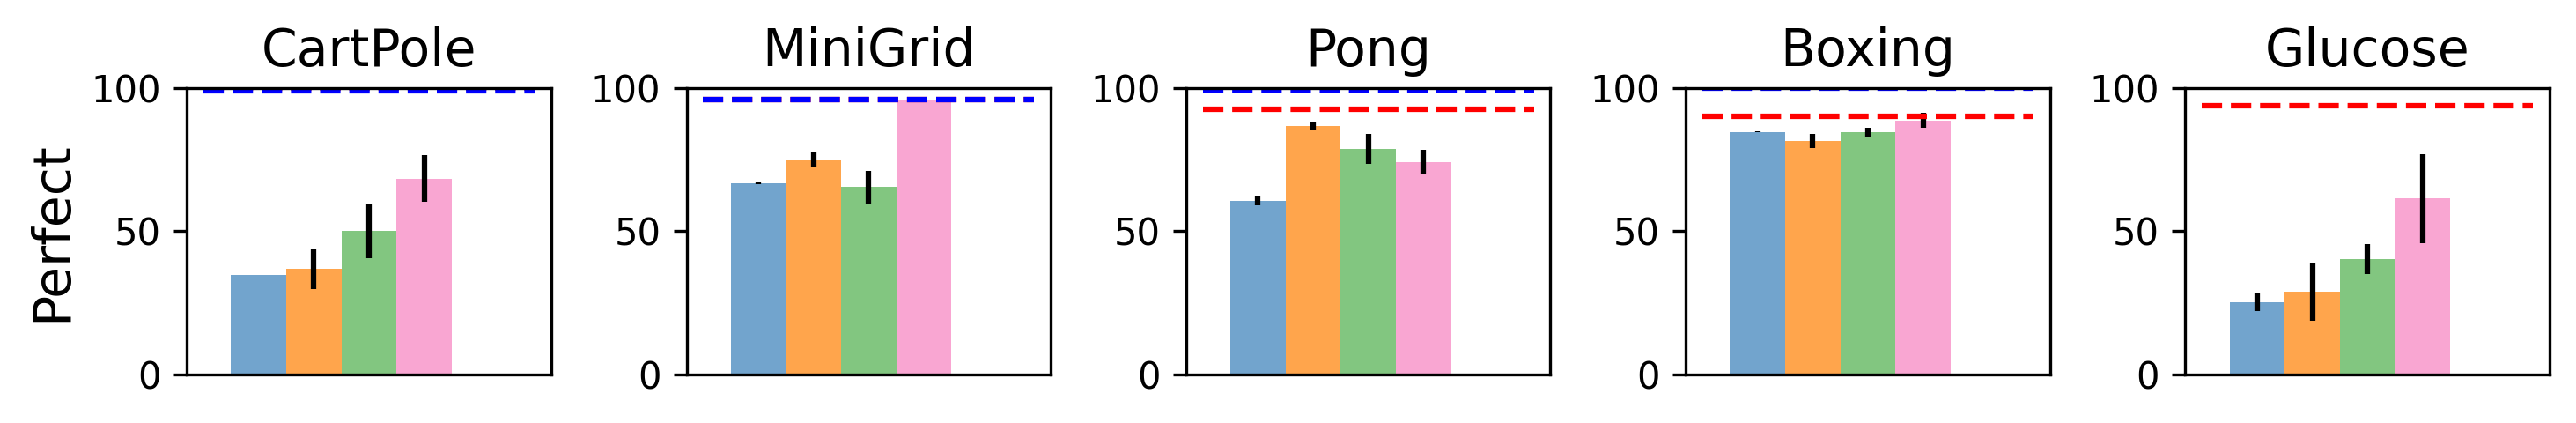

In [7]:
plot_dimensions = (1,len(perfect_environments))

titles = [[name_to_nice[i] for i in perfect_environments]]
y_labels = [["" for i in range(len(perfect_environments))]]
y_labels[0][0] = "Perfect"

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[0,100] for i in range(5)]],
    'x_ticks': [[[[],[]] for i in range(5)]]
}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles,y_labels=y_labels)

bar_format = {'color_palette': 'six_color', 'linewidth': 10, 'style_size': style_size,
}
plt.tight_layout()

for i in range(len(perfect_environments)):
    x_groups = list(range(len(all_performances_perfect[i][:-1])))
    y_vals = all_performances_perfect[i][1:]
    y_std = all_performances_perfect_std[i][1:]


    plot_bar(ax[0][i],x_groups,y_vals,y_std, methods_dict,bar_format)
    
    ax[0][i].hlines(all_performances_perfect[i][0],-0.25,1.25,label="All Concepts",color="red",linestyle="--")
    
    if i!=len(perfect_environments)-1:
        ax[0][i].hlines(all_baselines[i],-0.25,1.25,label="Ground Truth",color="blue",linestyle="--")

# legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 6, 'bbox_to_anchor': (0.1,-0.1),'fontsize': 14}
# create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/basic_comparison_methods_perfect.pdf",dpi=300, bbox_inches='tight')

5 six_color 1
5 six_color 1
5 six_color 1
5 six_color 1


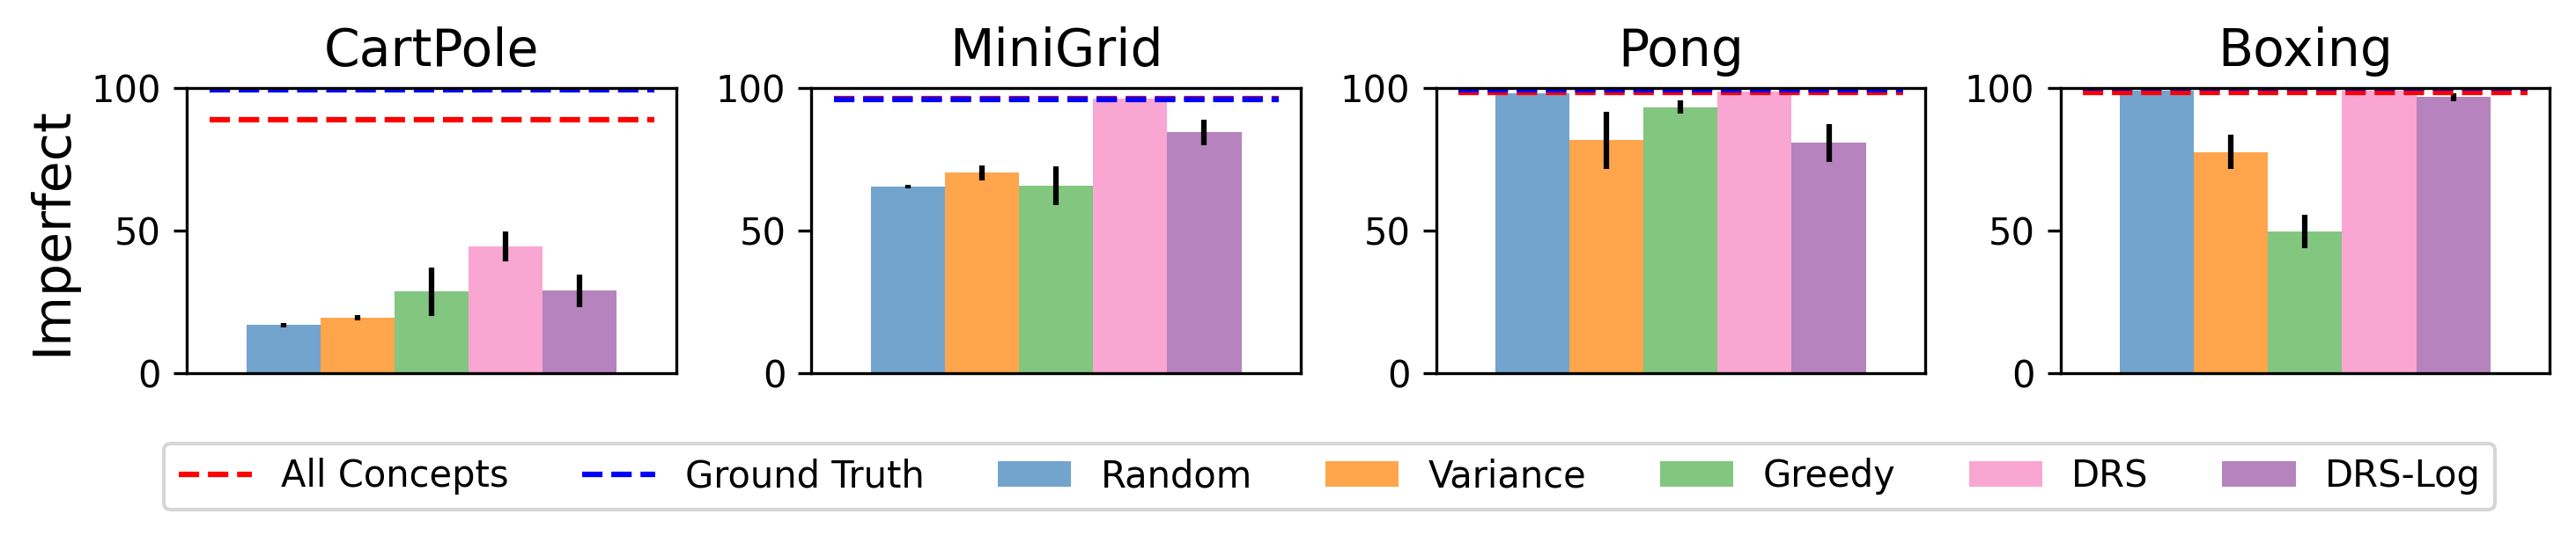

In [8]:
plot_dimensions = (1,len(imperfect_environments))

titles = [[name_to_nice[i] for i in imperfect_environments]]
y_labels = [["" for i in range(len(imperfect_environments))]]
y_labels[0][0] = "Imperfect"

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[0,100] for i in range(4)]],
    'x_ticks': [[[[],[]] for i in range(5)]]

}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles,y_labels=y_labels)

bar_format = {'color_palette': 'six_color', 'linewidth': 10, 'style_size': style_size,
}
plt.tight_layout()

for i in range(len(imperfect_environments)):
    x_groups = list(range(len(all_performances_imperfect[i][:-1])))
    y_vals = all_performances_imperfect[i][1:]
    y_std = all_performances_imperfect_std[i][1:]

    plot_bar(ax[0][i],x_groups,y_vals,y_std, methods_dict,bar_format)
    
    ax[0][i].hlines(all_performances_imperfect[i][0],-0.25,1.25,label="All Concepts",color="red",linestyle="--")
    ax[0][i].hlines(all_baselines[i],-0.25,1.25,label="Ground Truth",color="blue",linestyle="--")

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 7, 'bbox_to_anchor': (0.075
                                                                                                                ,-0.1),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/basic_comparison_methods_imperfect.pdf",dpi=300, bbox_inches='tight')

In [9]:
e = 'mini_grid'
m = 'lp_hybrid'
names = get_all_mini_grid_names()

matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                            'num_concepts_selected': num_concepts_selected[e],'experiment': 'perfect_comparison',
                                                            'method': m, 'gold_timesteps': gold_timesteps[e]})
for res in matching_params:
    c = [names[i] for i in res[m]['concepts']]
    print(c)

['X Pos_3', 'Y Pos_1', 'Dir_1', 'Dir_2', 'Dir_3', 'Key Y_1', 'Key Y_2', 'Key Y_3', 'Door Y_2', 'Right_1', 'Left_1']
['X Pos_1', 'Y Pos_1', 'Y Pos_2', 'Dir_1', 'Dir_2', 'Dir_3', 'Key X_1', 'Door Y_1', 'Door Open_0', 'Left_0', 'Up_0']
['X Pos_1', 'Y Pos_1', 'Y Pos_3', 'Dir_1', 'Dir_2', 'Dir_3', 'Key Y_1', 'Key Y_2', 'Door Y_2', 'Door Open_0', 'Left_0']
['X Pos_1', 'X Pos_2', 'Y Pos_1', 'Y Pos_2', 'Dir_1', 'Dir_2', 'Dir_3', 'Key X_1', 'Key Y_1', 'Door Y_1', 'Door Open_0']
['X Pos_3', 'Y Pos_1', 'Dir_1', 'Dir_2', 'Dir_3', 'Key Y_1', 'Key Y_3', 'Door Y_2', 'Door Open_0', 'Left_0', 'Up_0']
['X Pos_1', 'Y Pos_2', 'Dir_1', 'Dir_2', 'Dir_3', 'Key X_1', 'Door Y_1', 'Door Open_0', 'Left_0', 'Down_1', 'Up_1']


In [10]:
e = 'mini_grid'
m = 'greedy'
names = get_all_mini_grid_names()

matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                            'num_concepts_selected': num_concepts_selected[e],'experiment': 'perfect_comparison',
                                                            'method': m, 'gold_timesteps': gold_timesteps[e]})
for res in matching_params:
    c = [names[i] for i in res[m]['concepts']]
    print(c)

['Key Y_1', 'Y Pos_1', 'Up_0', 'Up_1', 'Right_0', 'Right_1', 'Y Pos_3', 'Door Y_2', 'Door Y_1', 'Door Open_1', 'Door Open_0']
['Left_1', 'Left_0', 'Door Open_0', 'Door Open_1', 'Y Pos_3', 'X Pos_1', 'X Pos_3', 'Key X_1', 'Y Pos_2', 'Key Y_2', 'Down_0']
['X Pos_3', 'X Pos_1', 'Door Open_1', 'Door Open_0', 'Down_1', 'Down_0', 'Left_1', 'Left_0', 'Key X_1', 'Y Pos_3', 'Dir_1']
['Up_0', 'Up_1', 'X Pos_1', 'Key Y_3', 'Down_1', 'Down_0', 'Left_1', 'Left_0', 'Y Pos_3', 'Door Y_1', 'Door Y_2']
['Door Y_1', 'Door Y_2', 'Door Open_1', 'Door Open_0', 'X Pos_3', 'Y Pos_2', 'X Pos_1', 'Down_0', 'Down_1', 'Key X_1', 'Left_1']
['Door Y_1', 'Door Y_2', 'Door Open_1', 'Door Open_0', 'X Pos_3', 'X Pos_1', 'Y Pos_1', 'Y Pos_3', 'Dir_1', 'Down_1', 'Down_0']


In [12]:
e = 'mini_grid'
m = 'entropy'
names = get_all_mini_grid_names()

matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                            'num_concepts_selected': num_concepts_selected[e],'experiment': 'perfect_comparison',
                                                            'method': m, 'gold_timesteps': gold_timesteps[e]})
for res in matching_params:
    c = [names[i] for i in res[m]['concepts']]
    print(c)

['Y Pos_3', 'Dir_1', 'Y Pos_1', 'Y Pos_2', 'Left_0', 'Left_1', 'Key X_1', 'Door Y_2', 'Up_1', 'Door Y_1', 'Up_0']
['Door Open_1', 'Dir_1', 'Y Pos_1', 'Y Pos_2', 'Door Y_1', 'Door Y_2', 'Up_1', 'Up_0', 'Left_1', 'Left_0', 'Key X_1']
['Y Pos_3', 'Dir_1', 'Y Pos_2', 'Y Pos_1', 'Key X_1', 'Up_0', 'Up_1', 'Door Y_1', 'Door Y_2', 'Left_0', 'Left_1']
['Y Pos_3', 'Y Pos_1', 'Dir_1', 'Y Pos_2', 'Left_0', 'Left_1', 'Up_0', 'Up_1', 'Door Y_1', 'Door Y_2', 'Key X_1']
['Y Pos_3', 'Dir_1', 'Y Pos_1', 'Y Pos_2', 'Up_1', 'Up_0', 'Key X_1', 'Door Y_1', 'Left_0', 'Door Y_2', 'Left_1']
['Y Pos_3', 'Dir_1', 'Y Pos_1', 'Key X_1', 'Y Pos_2', 'Up_0', 'Up_1', 'Door Y_2', 'Door Y_1', 'Left_0', 'Left_1']


In [13]:
all_performances_perfect[-1][-1]/all_performances_perfect[-1][-2]

1.5291434200218232

In [14]:
all_performances_perfect[0][-1]/all_performances_perfect[0][1]

1.9729512932516273

In [15]:
all_performances_perfect[-2][-2]/all_performances_perfect[-2][-1]

0.9542691316096107

In [16]:
all_performances_imperfect[0][-2]/all_performances_imperfect[0][2]

2.2763551326512474

In [17]:
all_performances_imperfect[1][-2]/np.max(all_performances_imperfect[1][1:-2])

1.3701124708585957

In [18]:
all_performances_imperfect[0][-1]/all_performances_imperfect[0][-2]

0.65379746914661

In [19]:
for j,e in enumerate(imperfect_environments):
    temp = []
    temp_std = []
    ours = []

    for m in ['lp_hybrid','multiple_log']:
        matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                    'num_concepts_selected': num_concepts_selected[e],'experiment': 'imperfect_comparison',
                                                                    'method': m, 'gold_timesteps': gold_timesteps[e]})
        
        ours.append([i[m]['concepts'] for i in matching_params])
    
    avg = []
    for i in ours[0]:
        for j in ours[1]:
            avg.append(len(set(i).intersection(set(j)))/len(j))
    print(np.mean(avg))

0.2962962962962963
0.3005050505050505
0.19736842105263158
0.2841435185185185


In [20]:
two_stage = []
basic_comparison = []
perfect_environments = ['cart_pole',"mini_grid","pong","boxing","glucose"]
perfect_methods = ["random","entropy","greedy","lp_hybrid"]

imperfect_environments = ['cart_pole',"mini_grid","pong","boxing"]
imperfect_methods = ["random","entropy","greedy","lp_hybrid","multiple_log"]

num_concepts_selected = {
    'cart_pole': 3,
    'mini_grid': 11, 
    'pong': 57,
    'boxing': 48,
    'glucose': 10
}

all_performances_k = []
all_performances_k_std = []

for j,e in enumerate(perfect_environments):
    temp_env = []
    temp_env_std = []

    for m in perfect_methods:
        temp = []
        temp_std = []

        for fraction_selected in [0.33,0.66,1]:
            matching_params = get_results_matching_parameters("imperfect","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                        'num_concepts_selected': round(num_concepts_selected[e]*fraction_selected),
                                                                        'method': m, 'gold_timesteps': gold_timesteps[e],'experiment': 'perfect_comparison'})


            if len(matching_params) == 0:
                matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                            'num_concepts_selected': round(num_concepts_selected[e]*fraction_selected),
                                                                            'method': m, 'gold_timesteps': gold_timesteps[e], 'experiment': 'perfect_comparison'})

            performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
            print("Perfect",e,m,round(num_concepts_selected[e]*fraction_selected),len([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]),[i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])],np.mean( [len(matching_params[i][m]['concepts']) for i in range(len(matching_params))]))

            if np.isnan(performance):
                performance = 0
            temp.append(performance)

            performance_std = method_scales_std[j](np.std([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))/len(matching_params)**.5
            temp_std.append(performance_std)

        temp_env.append(temp)
        temp_env_std.append(temp_std)
    all_performances_k.append(temp_env)
    all_performances_k_std.append(temp_env_std)


Perfect cart_pole random 1 6 [112.20744081172492, 112.26727066817666, 109.08910891089108, 109.04615384615384, 112.21468926553672, 110.4011111111111] 1.0
Perfect cart_pole random 2 6 [164.70364238410596, 164.03471074380164, 162.9688524590164, 165.13810316139768, 166.8873949579832, 165.74376039933443] 2.0
Perfect cart_pole random 3 6 [172.8411867364747, 174.26186291739896, 173.9106830122592, 172.74434782608697, 171.32413793103447, 173.65034965034965] 3.0
Perfect cart_pole entropy 1 6 [39.323228346456695, 39.39984195969972, 39.69490851233095, 106.55401069518716, 110.4011111111111, 104.5215110178384] 1.0
Perfect cart_pole entropy 2 6 [113.84650630011454, 116.17605633802818, 121.38536585365854, 110.95089285714286, 113.64530892448512, 40.965531391054576] 2.0
Perfect cart_pole entropy 3 6 [122.23645320197045, 122.98019801980197, 126.8764331210191, 325.8973509933775, 117.70567375886525, 286.7325581395349] 3.0
Perfect cart_pole greedy 1 6 [112.20744081172492, 39.69490851233095, 110.401111111111

[[0, 1, 2], [0, 1, 2], [0, 1, 2], [0, 1, 2]] [[22.17419248711981, 32.98254880352131, 34.6244189357868], [14.663153721420802, 20.56565538881613, 36.7476222411523], [19.63458725973375, 27.94804256474879, 50.051114595609846], [15.050209626764033, 57.97995803759576, 68.3122921174467]]
[[0, 1, 2], [0, 1, 2], [0, 1, 2], [0, 1, 2]] [[28.64161625265783, 42.00020647756861, 66.6297584031264], [16.029280306353712, 27.16561506042331, 75.06393424410332], [19.31399734461178, 31.22801254728885, 65.381706705816], [37.03926348726047, 91.01353608945941, 95.89120170656517]]
[[0, 1, 2], [0, 1, 2], [0, 1, 2], [0, 1, 2]] [[11.167132169835464, 91.30662764066125, 60.68783068783068], [11.37401765343028, 28.775711195670983, 86.63245741618756], [52.92601564922994, 65.98186681097432, 78.76407860348816], [6.1894224003329965, 43.08448767069457, 74.16119099154814]]
[[0, 1, 2], [0, 1, 2], [0, 1, 2], [0, 1, 2]] [[90.03011070691086, 75.96210283278806, 84.6633139020794], [75.10493862720809, 84.7077647000449, 81.61758125

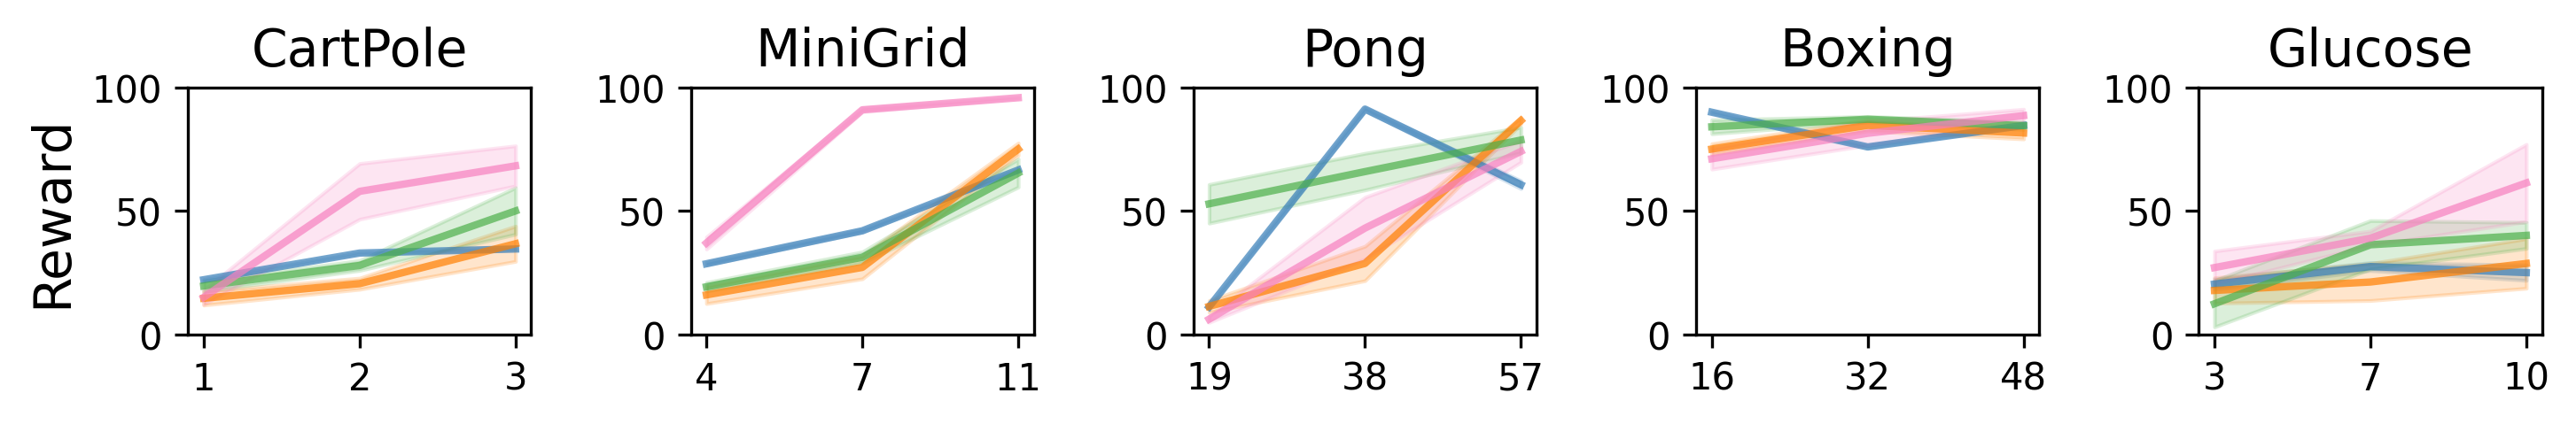

In [21]:
plot_dimensions = (1,len(perfect_environments))

titles = [[name_to_nice[i] for i in perfect_environments]]
y_labels = [["" for i in range(5)]]
y_labels[0][0] = "Reward"

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[0,100],[0,100],[0,100],[0,100],[0,100]]],
    'x_ticks': [[[[0,1,2],[round(num_concepts_selected[perfect_environments[i]]*[0.33,0.66,1][j]) for j in range(3)]] for i in range(5)] for j in range(1)],

}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles,y_labels=y_labels)

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

for i in range(len(perfect_environments)):
    y_vals = all_performances_k[i]

    x_groups = [list(range(len(j))) for j in y_vals]

    print(x_groups,y_vals)

    plot_line(ax[0][i],x_groups,y_vals,all_performances_k_std[i], perfect_methods,line_format)
    
fig.savefig("../../results/figures/perfect_varied_k.pdf",dpi=300, bbox_inches='tight')

In [22]:
all_performances_k[-1][2][1]/all_performances_k[-1][3][1]

0.9313762358283998

In [23]:
all_performances_k[-1][3][2]/all_performances_k[-1][2][2]

1.5291434200218232

In [24]:
np.mean(np.array(all_performances_k)[0][-1])/np.mean(np.array(all_performances_k)[0][-4])

1.574299768741472

In [25]:
np.mean(np.array(all_performances_k)[1][-1])/np.mean(np.array(all_performances_k)[1][-4])

1.6313937628920734

In [26]:
two_stage = []
basic_comparison = []
perfect_environments = ['cart_pole',"mini_grid","pong","boxing","glucose"]
perfect_methods = ["random","entropy","greedy","lp_hybrid"]

imperfect_environments = ['cart_pole',"mini_grid","pong","boxing"]
imperfect_methods = ["random","entropy","greedy","lp_hybrid","multiple_log"]

num_concepts_selected = {
    'cart_pole': 3,
    'mini_grid': 11, 
    'pong': 57,
    'boxing': 48,
    'glucose': 10
}

all_performances_k = []
all_performances_k_std = []
for j,e in enumerate(imperfect_environments):
    temp_env = []
    temp_env_std = []
    for m in imperfect_methods:
        temp = []
        temp_std = []

        for fraction_selected in [0.33,0.66,1]:
            matching_params = get_results_matching_parameters("imperfect","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                        'num_concepts_selected': round(num_concepts_selected[e]*fraction_selected),
                                                                        'method': m, 'gold_timesteps': gold_timesteps[e],'experiment': 'imperfect_comparison'})


            if len(matching_params) == 0:
                matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                            'num_concepts_selected': round(num_concepts_selected[e]*fraction_selected),
                                                                            'method': m, 'gold_timesteps': gold_timesteps[e], 'experiment': 'imperfect_comparison'})

            performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
            print("Perfect",e,m,len(matching_params),round(num_concepts_selected[e]*fraction_selected),[i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])],np.mean( [len(matching_params[i][m]['concepts']) for i in range(len(matching_params))]))

            if np.isnan(performance):
                performance = 0
            temp.append(performance)

            performance = method_scales_std[j](np.std([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))/len(matching_params)**.5
            temp_std.append(performance)

        temp_env.append(temp)
        temp_env_std.append(temp_std)
    all_performances_k.append(temp_env)
    all_performances_k_std.append(temp_env_std)


Perfect cart_pole random 6 1 [77.62928348909658, 92.76815642458101, 73.79748706577975, 91.46464646464646, 75.72892938496584, 98.66897918731418] 1.0
Perfect cart_pole random 6 2 [97.25, 91.45814167433302, 74.65917602996255, 77.48251748251748, 80.33199033037873, 92.71508379888269] 2.0
Perfect cart_pole random 6 3 [80.99918765231519, 70.50247699929228, 96.16216216216216, 91.35321100917432, 91.4954128440367, 78.28031496062992] 3.0
Perfect cart_pole entropy 6 1 [31.40943396226415, 33.991150442477874, 31.630145661811273, 91.09762773722628, 64.31891542930923, 77.62928348909658] 1.0
Perfect cart_pole entropy 6 2 [92.36700648748841, 37.36849981294426, 85.26666666666667, 135.04347826086956, 87.7455985915493, 96.31431334622825] 2.0
Perfect cart_pole entropy 6 3 [103.40602284527519, 99.3562874251497, 94.5127962085308, 115.49361207897793, 87.43195785776997, 84.42408821034775] 3.0
Perfect cart_pole greedy 6 1 [69.35768963117606, 75.72892938496584, 91.46464646464646, 92.76815642458101, 31.40943396226

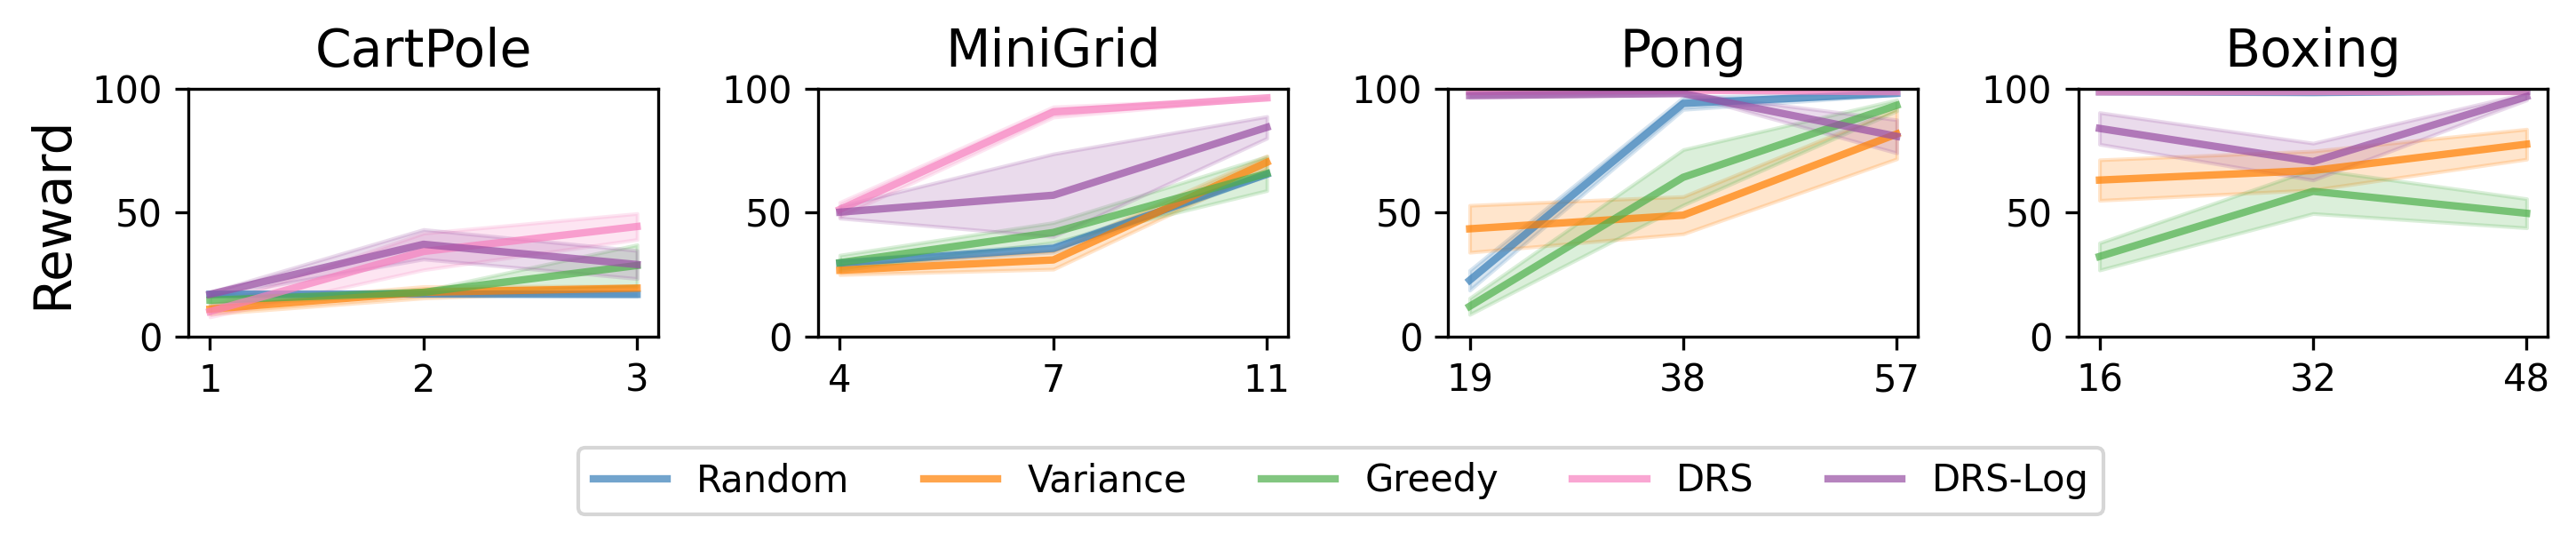

In [27]:
plot_dimensions = (1,len(imperfect_environments))

titles = [[name_to_nice[i] for i in imperfect_environments]]
y_labels = [["" for i in range(5)]]
y_labels[0][0] = "Reward"

sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[0,100],[0,100],[0,100],[0,100],[0,100]]],
    'x_ticks': [[[[0,1,2],[round(num_concepts_selected[imperfect_environments[i]]*[0.33,0.66,1][j]) for j in range(3)]] for i in range(4)] for j in range(1)],
}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles,y_labels=y_labels)

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

for i in range(len(imperfect_environments)):
    y_vals = all_performances_k[i]

    x_groups = [list(range(len(j))) for j in y_vals]

    plot_line(ax[0][i],x_groups,y_vals,all_performances_k_std[i], [methods_to_nice[m] for m in imperfect_methods],line_format)
    
legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 6, 'bbox_to_anchor': (0.23,-0.1),'fontsize': 18}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/imperfect_varied_k.pdf",dpi=300, bbox_inches='tight')

In [28]:
all_performances_k[2][3][0]/all_performances_k[2][1][0]

2.2761111701737624

In [29]:
all_performances_k[3][3][0]/all_performances_k[3][2][0]

3.06049953265134

In [30]:
all_performances_k_std[3]

[[0.12197723248669999, 0.5519716154247323, 0.13737313077082952],
 [8.179450616232215, 7.840670413669222, 6.0582988921650776],
 [5.485572875130842, 8.971900303794985, 5.876819131261652],
 [0.2560274270386264, 0.2001826553486815, 0.20783511219800874],
 [6.385866129846147, 7.438804286898259, 1.3593735473935158]]

In [31]:
two_stage = []
basic_comparison = []
perfect_environments = ['cart_pole',"mini_grid","pong","boxing","glucose"]
perfect_methods = ["random","entropy","greedy","lp_hybrid"]

imperfect_environments = ['cart_pole',"mini_grid","pong","boxing"]
imperfect_methods = ["random","entropy","greedy","lp_hybrid","multiple_log"]

num_concepts_selected = {
    'cart_pole': 3,
    'mini_grid': 11, 
    'pong': 57,
    'boxing': 48,
    'glucose': 10
}

all_performances_k = []
for j,e in enumerate(perfect_environments):
    temp_env = []
    for m in perfect_methods:
        temp = []

        for fraction_selected in [0.33,0.66,1]:
            matching_params = get_results_matching_parameters("imperfect","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                        'num_concepts_selected': round(num_concepts_selected[e]*fraction_selected),
                                                                        'method': m, 'gold_timesteps': gold_timesteps[e]})


            if len(matching_params) == 0:
                matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                            'num_concepts_selected': round(num_concepts_selected[e]*fraction_selected),
                                                                            'method': m, 'gold_timesteps': gold_timesteps[e], 'experiment': 'perfect_comparison'})

            performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
            print("Perfect",e,m,round(num_concepts_selected[e]*fraction_selected),len([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]),[i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])],np.mean( [len(matching_params[i][m]['concepts']) for i in range(len(matching_params))]))

            if np.isnan(performance):
                performance = 0
            temp.append(performance)
        temp_env.append(temp)
    all_performances_k.append(temp_env)


Perfect cart_pole random 1 12 [112.20744081172492, 112.26727066817666, 77.62928348909658, 92.76815642458101, 109.08910891089108, 109.04615384615384, 112.21468926553672, 73.79748706577975, 91.46464646464646, 110.4011111111111, 75.72892938496584, 98.66897918731418] 1.0
Perfect cart_pole random 2 12 [164.70364238410596, 164.03471074380164, 97.25, 162.9688524590164, 165.13810316139768, 91.45814167433302, 166.8873949579832, 165.74376039933443, 74.65917602996255, 77.48251748251748, 80.33199033037873, 92.71508379888269] 2.0
Perfect cart_pole random 3 6 [172.8411867364747, 174.26186291739896, 173.9106830122592, 172.74434782608697, 171.32413793103447, 173.65034965034965] 3.0
Perfect cart_pole entropy 1 12 [31.40943396226415, 39.323228346456695, 33.991150442477874, 39.39984195969972, 31.630145661811273, 91.09762773722628, 39.69490851233095, 106.55401069518716, 110.4011111111111, 64.31891542930923, 104.5215110178384, 77.62928348909658] 1.0
Perfect cart_pole entropy 2 12 [92.36700648748841, 113.84

Perfect cart_pole entropy 3 6 [122.23645320197045, 122.98019801980197, 126.8764331210191, 325.8973509933775, 117.70567375886525, 286.7325581395349] 3.0
Perfect cart_pole greedy 1 12 [69.35768963117606, 112.20744081172492, 75.72892938496584, 39.69490851233095, 91.46464646464646, 92.76815642458101, 110.4011111111111, 31.40943396226415, 112.26727066817666, 77.62928348909658, 109.08910891089108, 105.37777777777778] 1.0
Perfect cart_pole greedy 2 12 [92.28385899814471, 74.65917602996255, 85.81411359724613, 92.71787709497207, 87.24802804557406, 164.70364238410596, 110.81291759465479, 158.9823717948718, 125.203026481715, 111.68385650224215, 101.03853955375254, 167.05546218487396] 2.0
Perfect cart_pole greedy 3 6 [326.2119205298013, 167.77871621621622, 110.20066518847007, 286.7325581395349, 163.0935960591133, 447.5159817351598] 3.0
Perfect cart_pole lp_hybrid 1 12 [110.4011111111111, 112.21468926553672, 40.04773365423185, 40.02927024859663, 32.347150259067355, 98.66897918731418, 39.76733067729

In [32]:
num_concepts_selected = [[1,2,3],[3,6,11],[57//4,57//2,57],[12,24,48],[2,5,10]]
accuracies = [0.75,0.85,0.95]
max_perf = [i+0.001 for i in all_baselines]
max_perf[3] = 100
max_perf[2] = 21
heatmap_by_env = [[[0 for k in range(len(num_concepts_selected[i]))] for j in accuracies] for i in range(len(perfect_environments))]

for i,e in enumerate(perfect_environments):
    for j,acc in enumerate(accuracies):
        for k,n in enumerate(num_concepts_selected[i]):
            matching_params = get_results_matching_parameters("imperfect","",{'environment_string': e, 'concept_accuracy': acc,
                        'num_concepts_selected': n, 'training_timesteps': training_times[e]})
            print(e,acc,n,len(matching_params),[m['multiple']['reward'] for m in matching_params],round(np.mean([m['multiple']['reward'] for m in matching_params])/max_perf[i],2)*100)
            if len(matching_params) > 0 and 'multiple' in matching_params[0]:
                heatmap_by_env[i][j][k] = round(method_scales[i](np.mean([m['multiple']['reward'] for m in matching_params])))

cart_pole 0.75 1 6 [35.4499645138396, 35.187455954897814, 35.25035310734463, 61.2826354679803, 35.94704610951008, 34.957282913165265] 40.0
cart_pole 0.75 2 6 [79.38609112709833, 82.30008244023084, 53.32922912205567, 79.6824, 79.27149681528662, 36.13427433948607] 69.0
cart_pole 0.75 3 6 [81.71993410214168, 52.06054279749478, 85.76055124892335, 84.05583756345177, 52.31529164477141, 86.0242214532872] 74.0
cart_pole 0.85 1 6 [37.74442344045369, 76.51382488479263, 38.20160673297628, 37.895596051632495, 78.00156617071261, 77.79000780640125] 57.99999999999999
cart_pole 0.85 2 6 [217.3010989010989, 207.79535864978902, 38.70702367093519, 164.48922056384743, 39.24095911949686, 199.81135902636916] 146.0
cart_pole 0.85 3 6 [67.56610169491526, 196.43027888446215, 70.90056818181819, 198.72489959839356, 196.46626984126985, 199.33737373737372] 156.0
cart_pole 0.95 1 6 [102.74406604747162, 39.351851851851855, 39.590007930214114, 39.17896389324961, 39.07713390759593, 103.13097713097713] 61.0
cart_pole 0

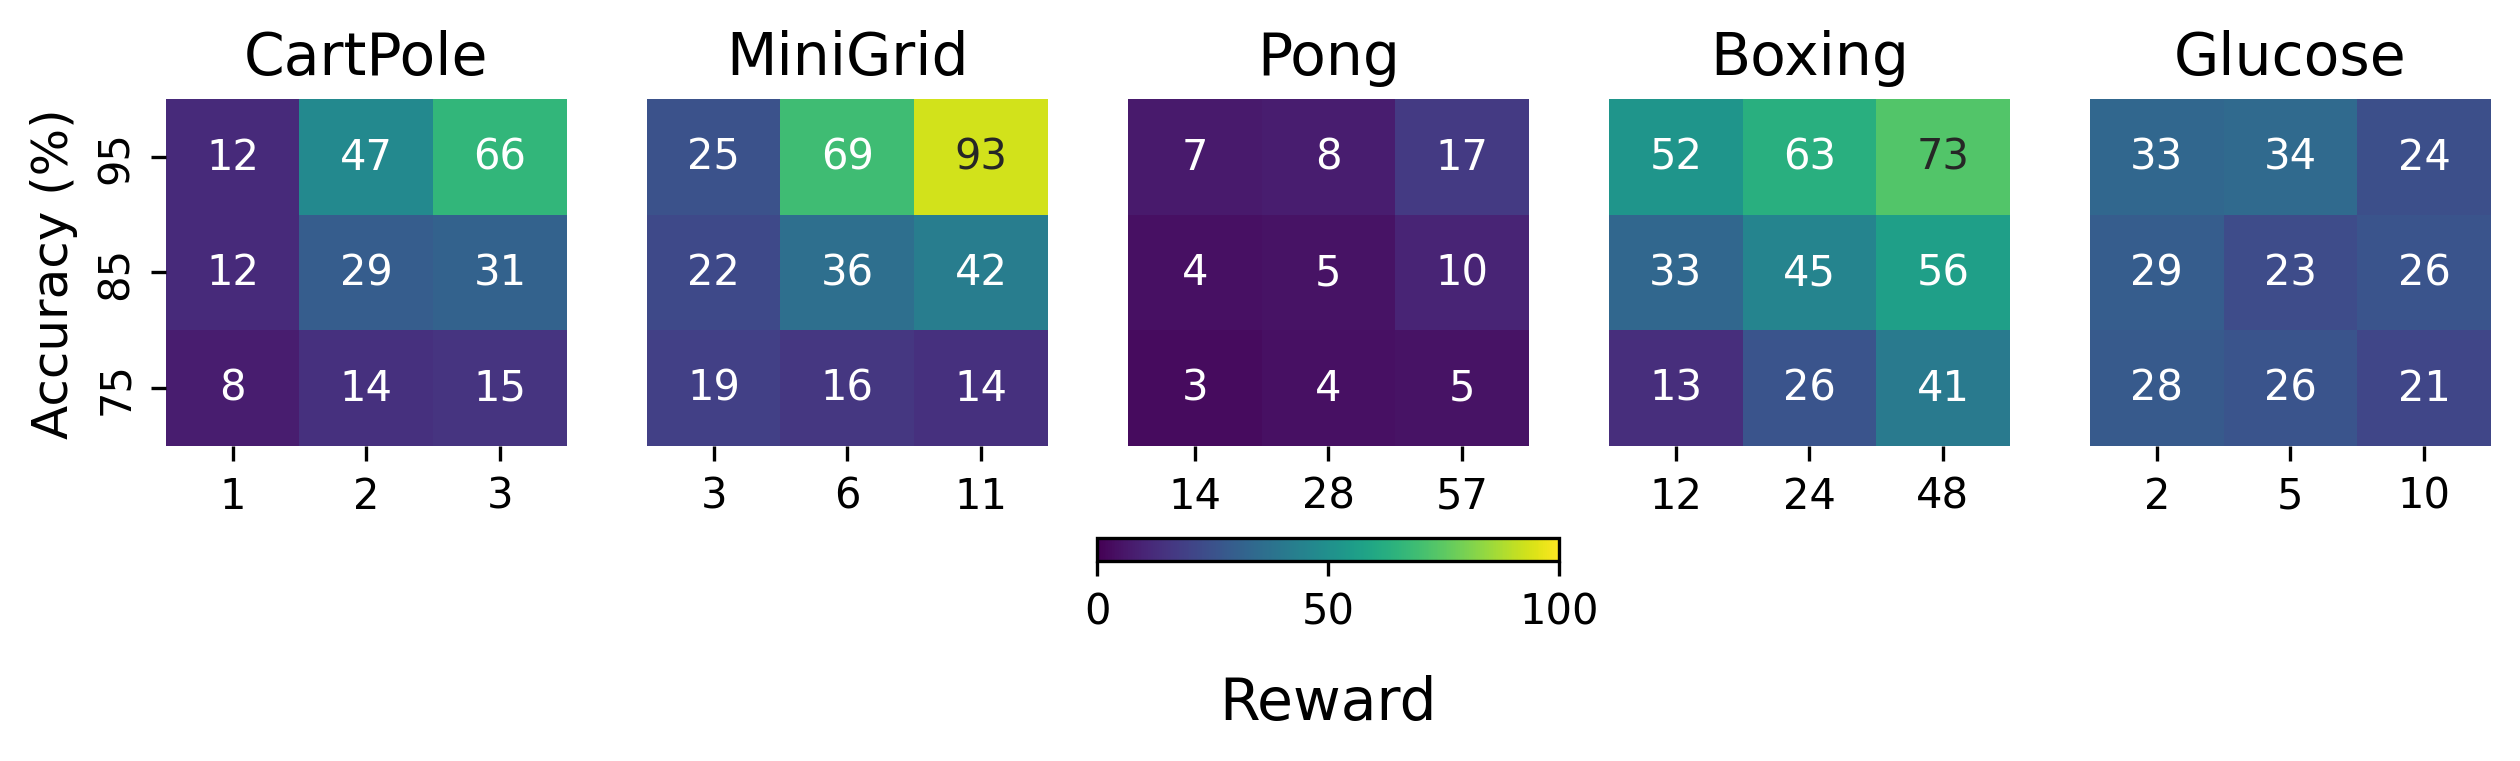

In [33]:
plot_dimensions = (1,len(perfect_environments))
def index_to_tuple(i):
    return (0,i)

def flatten_to_square(lst):
    res = [[0 for i in range(len(perfect_environments))] for j in range(1)]

    for i in range(len(lst)):
        x,y = index_to_tuple(i)
        res[x][y] = lst[i]
    
    return res

titles = [[name_to_nice[i] for i in perfect_environments]]
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'has_grid': False, 
}

import matplotlib as mpl

fig, ax = create_axes(plot_dimensions, overall_format, titles=titles)

# Draw all heatmaps WITHOUT colorbars
for i in range(len(perfect_environments)):
    annot = ["75","85","95"] 
    if i!=0:
        annot = [] 
    sns.heatmap(
        heatmap_by_env[i],
        ax=ax[0][i],
        cmap="viridis",
        xticklabels=num_concepts_selected[i],
        yticklabels=annot,
        vmin=0, vmax=100,   # ensure consistent scaling
        cbar=False,
        annot=True
    )
    ax[0][i].invert_yaxis()

# ---- GLOBAL HORIZONTAL COLORBAR (0 to 1) ----
norm = mpl.colors.Normalize(vmin=0, vmax=100)
sm = mpl.cm.ScalarMappable(norm=norm, cmap="viridis")
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=[a for row in ax for a in row],
    orientation='horizontal',
    fraction=0.05,    # thinner bar
    pad=0.20          # spacing from subplots
)
cbar.set_label("Reward",fontsize=14,labelpad=10)

ax[0][0].set_ylabel("Accuracy (%)", fontsize=12)

fig.savefig(
    "../../results/figures/num_concepts_accuracy.pdf",
    dpi=300,
    bbox_inches='tight')


In [34]:
num_concepts_selected = 11
concept_accuracies = [0.75,0.85,0.95]
environment = "mini_grid"
rewards = []
stds = []

for acc in concept_accuracies:
    temp = []
    temp_std = []
    for t in [250000,500000,750000,1000000]:
        matching_params = get_results_matching_parameters("imperfect","",{'environment_string': environment,'num_concepts_selected': num_concepts_selected, 'concept_accuracy':acc, 'training_timesteps': t})
        print(acc,t,len(matching_params))
        temp.append(method_scales[1](np.mean([i['multiple']['reward'] for i in matching_params])))
        temp_std.append(method_scales_std[1](np.std([i['multiple']['reward'] for i in matching_params]))/len(matching_params)**.5)

    rewards.append(temp)
    stds.append(temp_std)
rewards_accuracy = np.array(rewards)
std_accuracy = np.array(stds)

0.75 250000 6
0.75 500000 6
0.75 750000 6
0.75 1000000 6
0.85 250000 6
0.85 500000 6


0.85 750000 6
0.85 1000000 6
0.95 250000 6
0.95 500000 6
0.95 750000 6
0.95 1000000 6


In [35]:
acc = 0.9
num_concepts_selected = [3,6,11]
environment = "mini_grid"
total_concepts = 44
rewards = []
stds_concepts = []

for n in num_concepts_selected:
    temp = []
    temp_std = []
    for t in [250000,500000,750000,1000000]:
        matching_params = get_results_matching_parameters("imperfect","",{'environment_string': environment,'num_concepts_selected': n, 'concept_accuracy':0.95, 'training_timesteps': t})
        print(n,t,len(matching_params))
        temp.append(method_scales[1](np.mean([i['multiple']['reward'] for i in matching_params])))
        temp_std.append(method_scales_std[1](np.std([i['multiple']['reward'] for i in matching_params]))/len(matching_params)**.5)

    rewards.append(temp)
    stds_concepts.append(temp_std)
rewards_num_concepts = np.array(rewards)
stds_concepts = np.array(stds_concepts)
rewards_num_concepts

3 250000 6
3 500000 6
3 750000 6
3 1000000 6
6 250000 6
6 500000 6


6 750000 6
6 1000000 6
11 250000 6
11 500000 6
11 750000 6
11 1000000 6


array([[16.81985551, 25.09623208, 31.92368113, 40.55536551],
       [43.08498164, 68.93250494, 73.8196606 , 75.81480353],
       [55.63515471, 92.52825389, 93.5562115 , 93.8398145 ]])

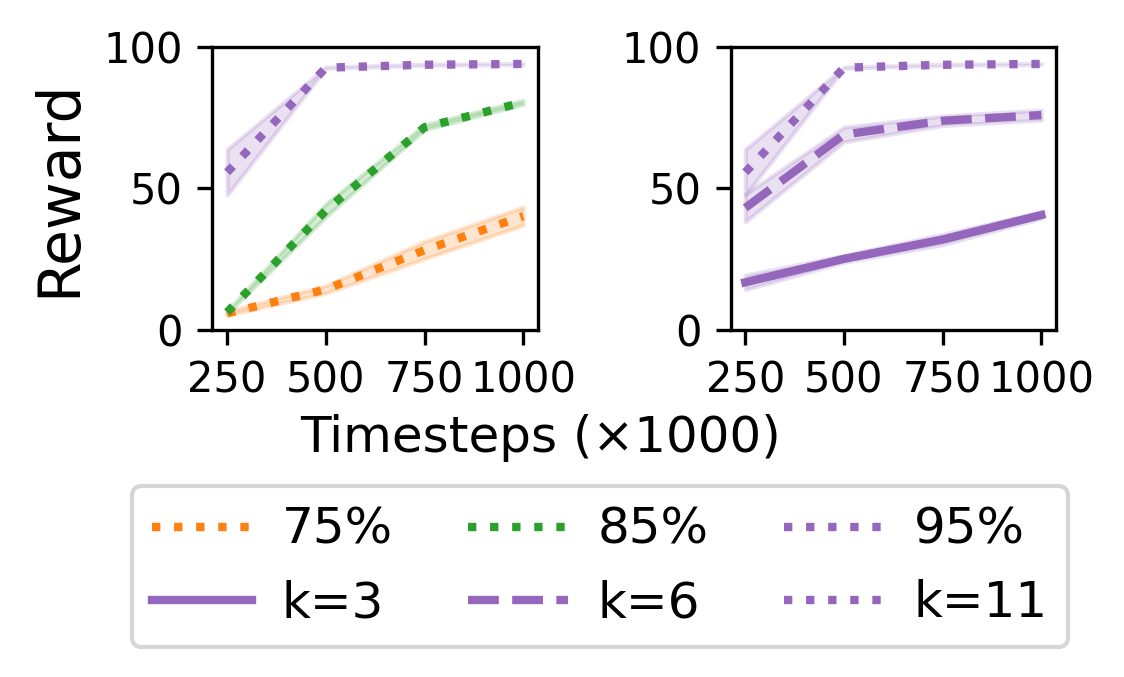

In [36]:
plot_dimensions = (1, 2)

overall_format = {
    'figsize': (4, 2),
    'style_size': style_size,
    'has_grid': False,
    'x_ticks': [[[[0, 1, 2, 3], ["250", "500", "750", "1000"]] for _ in range(2)]],
    'y_ticks': [[[[0, 50, 100], ["0", "50", "100"]] for _ in range(2)]],
    'y_lim': [[[0, 100] for _ in range(2)]],
}

fig, ax = create_axes(
    plot_dimensions,
    overall_format,
    y_labels=[["Reward", ""]],
    x_labels=[["", ""]],
    sup_x_label="",
)
fig.supxlabel("Timesteps (×1000)", y=0.13)

plt.tight_layout()

# -----------------------------
# Shared encodings
# -----------------------------
accuracy_labels = [f"{int(a * 100)}%" for a in concept_accuracies]
accuracy_palette = 'three_color_primary'

k_linestyles = ['-', '--', ':']
k_labels = [f"k={k}" for k in num_concepts_selected]

x_groups = [list(range(4)) for _ in range(3)]

# -----------------------------
# Left panel: vary accuracy
# -----------------------------
line_format_left = {
    'color_palette': accuracy_palette,
    'linewidth': 2,
    'linestyle': k_linestyles[-1],   # fixed style
}

plot_line(
    ax[0][0],
    x_groups,
    rewards_accuracy,
    std_accuracy,
    accuracy_labels,
    line_format_left,
)

ax[0][0].set_title("")

# -----------------------------
# Right panel: vary k
# -----------------------------
line_format_right = {
    'color_palette': "#9467bd",   # same colors = same accuracy
    'linewidth': 2,
    'linestyle': k_linestyles,            # style encodes k
}

plot_line(
    ax[0][1],
    x_groups,
    rewards_num_concepts,
    stds_concepts,
    k_labels,
    line_format_right,
)

ax[0][1].set_title("")

# -----------------------------
# Legends
# -----------------------------
# ax[0][0].legend(
#     title="Acc.",
#     loc='lower left',
#     fontsize=12,
#     title_fontsize=12,
#     ncols=3
# )

# ax[0][1].legend(
#     title="k",
#     loc='lower left',
#     fontsize=12,
#     title_fontsize=12,
#     ncols=3
# )

handles_left, labels_left = ax[0][0].get_legend_handles_labels()
handles_right, labels_right = ax[0][1].get_legend_handles_labels()

# Explicit row-wise ordering
handles = [
    handles_left[0],handles_right[0], handles_left[1], 
     handles_right[1], handles_left[2], handles_right[2],
]
labels = [
    labels_left[0],  labels_right[0], labels_left[1], 
   labels_right[1], labels_left[2], labels_right[2],
]
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3,
    fontsize=12,
    frameon=True,
    columnspacing=1.5,
    handletextpad=0.6,
    bbox_to_anchor=(0.55, -0.22),
)


plt.tight_layout()
fig.subplots_adjust(bottom=0.35)

# -----------------------------
# Save
# -----------------------------
fig.savefig(
    "../../results/figures/accuracy_num_concepts.pdf",
    dpi=300,
    bbox_inches='tight',
)


In [37]:
two_stage = []
basic_comparison = []
perfect_environments = ['cart_pole',"mini_grid","pong","boxing"]
imperfect_methods = ["random","entropy","greedy","lp_hybrid","multiple_log"]

intervention_probability = [0.25,0.5,0.75]

num_concepts_selected = {
    'cart_pole': 3,
    'mini_grid': 11, 
    'pong': 57,
    'boxing': 48,
    'glucose': 10
}

cart_pole_interventions = []
e = "cart_pole"
cart_pole_interventions.append(all_performances_imperfect[0][1:])
cart_pole_interventions_std = []
cart_pole_interventions_std.append(all_performances_imperfect[0][1:])
for i in intervention_probability:
    temp = []
    temp_std = []
    for m in imperfect_methods:
        matching_params = get_results_matching_parameters("intervention","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                    'num_concepts_selected': num_concepts_selected[e],
                                                                    'method': m, 'intervention_prob': i})
        if len(matching_params) > 0:
            performance = method_scales[0](np.mean([i[m]['reward'] for i in matching_params]))
            temp.append(performance)

            performance = method_scales[0](np.mean([i[m]['reward'] for i in matching_params]))/len(matching_params)**.5
            temp_std.append(performance)
        else:
            temp.append(0.0001)
            temp_std.append(0)
        print(i,m,len(matching_params))
    cart_pole_interventions.append(temp)
    cart_pole_interventions_std.append(temp_std)
intervention_probability.append(1.0)
intervention_probability = [0.0] + intervention_probability
cart_pole_interventions.append((all_performances_perfect[0][1:]+all_performances_perfect[0][-1:]))
cart_pole_interventions_std.append((all_performances_perfect_std[0][1:]+all_performances_perfect_std[0][-1:]))

0.25 random 3
0.25 entropy 3
0.25 greedy 3
0.25 lp_hybrid 3
0.25 multiple_log 3
0.5 random 6
0.5 entropy 6
0.5 greedy 6
0.5 lp_hybrid 6
0.5 multiple_log 6
0.75 random 3
0.75 entropy 3
0.75 greedy 3
0.75 lp_hybrid 3
0.75 multiple_log 3


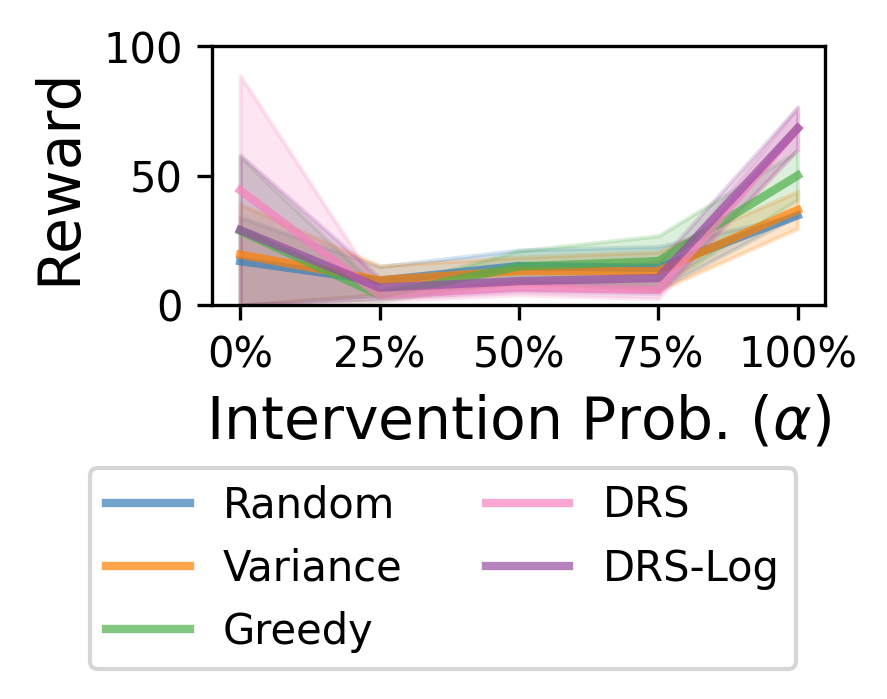

In [38]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,1)
titles = [[""]]
y_labels = [["Reward"]]

sup_y_label = ""
overall_format = {'figsize':(3.3,2),
    'style_size': style_size,
    'has_grid': False, 
    'x_ticks': [[[list(range(len(intervention_probability))),["0%","25%","50%","75%","100%"]] for i in range(5)] for j in range(1)],
    'y_lim': [[[0,100]]]
}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles,x_labels=[["Intervention Prob. ($\\alpha$)"]],y_labels=y_labels)

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

x_groups = [list(range(len(intervention_probability))) for j in imperfect_methods]
y_vals = np.array(cart_pole_interventions).T
y_std = np.array(cart_pole_interventions_std).T
plot_line(ax[0][0],x_groups,y_vals,y_std,['Random','Variance','Greedy','DRS','DRS-Log'],line_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 2, 'bbox_to_anchor': (0.13,-0.25),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/intervention_percent.pdf",dpi=300, bbox_inches='tight')


In [39]:
cart_pole_interventions[2][3]/cart_pole_interventions[2][2],cart_pole_interventions[2][4]/cart_pole_interventions[2][2]

(0.4520671227708072, 0.6205120808923854)

In [40]:
cart_pole_interventions[3][3]/cart_pole_interventions[3][2],cart_pole_interventions[3][4]/cart_pole_interventions[3][2]

(0.34587512114781827, 0.6144148562386864)

In [41]:
imperfect_methods = ["random","entropy","greedy","lp_hybrid","multiple_log"]


In [108]:
import numpy as np

# ------------------------
# Global config
# ------------------------
ENV_CONFIG = {
    "cart_pole": dict(timesteps=training_times["cart_pole"], scale_idx=0),
    "mini_grid": dict(timesteps=250_000, scale_idx=1),
    "pong":      dict(timesteps=4_000_000, scale_idx=2),
    "boxing":    dict(timesteps=2_000_000, scale_idx=3),
}

INTERVENTION_PROBS = [0.25, 0.5, 0.75]

NUM_CONCEPTS = {
    'cart_pole': 3,
    'mini_grid': 11,
    'pong': 57,
    'boxing': 48,
}

# ------------------------
# Core helpers
# ------------------------
def get_method_performance(env, p):
    """Return reward per method at intervention prob p."""
    cfg = ENV_CONFIG[env]
    out = []
    for m in imperfect_methods:
        params = get_results_matching_parameters(
            "intervention", "",
            dict(
                environment_string=env,
                training_timesteps=cfg["timesteps"],
                num_concepts_selected=NUM_CONCEPTS[env],
                method=m,
                intervention_prob=p,
            )
        )
        if len(params) > 0:
            r = np.mean([i[m]["reward"] for i in params])
            out.append(method_scales[cfg["scale_idx"]](r))
        else:
            out.append(1e-4)
    return out


def compute_accuracy_tradeoff(env):
    """Return baseline_combo, intervention_combo."""
    cfg = ENV_CONFIG[env]

    # --- baseline + intervention rewards ---
    baseline_rewards = all_performances_imperfect[0][1:]
    intervention_rewards = get_method_performance(env, 0.5)

    # --- concept accuracies ---
    params = get_results_matching_parameters(
        "intervention", "",
        dict(
            environment_string=env,
            training_timesteps=cfg["timesteps"],
            num_concepts_selected=NUM_CONCEPTS[env],
            method="multiple",
            intervention_prob=0.5,
        )
    )
    accuracies = np.array(params[0]["concept_accuracy"])

    selected = []
    for m in imperfect_methods:
        p = get_results_matching_parameters(
            "intervention", "",
            dict(
                environment_string=env,
                training_timesteps=cfg["timesteps"],
                num_concepts_selected=NUM_CONCEPTS[env],
                method=m,
                intervention_prob=0.5,
            )
        )

        selected.append([i[m]["concepts"] for i in p])

    for i in selected:
        for j in i:
            print(len(j),accuracies[j],np.mean(accuracies[j]))

    baseline_acc = np.array([np.mean([np.mean(accuracies[j]) for j in i]) for i in selected])



    # intervention-adjusted accuracy
    p = 0.5
    intervention_acc = []
    for i in selected:
        intervention_acc.append(np.mean([
            np.mean(p * np.ones(len(k)) + (1 - p) * accuracies[k])
            for k in i
        ]))

    baseline_combo = np.column_stack([baseline_acc, baseline_rewards])
    
    intervention_combo = np.column_stack([intervention_acc, intervention_rewards])

    return baseline_combo, intervention_combo


# ------------------------
# Compute all environments
# ------------------------
results = {
    env: compute_accuracy_tradeoff(env)
    for env in ["cart_pole", "mini_grid", "pong", "boxing"]
}


[[1, 7, 10], [1, 4, 7], [1, 7, 10], [1, 7, 10], [1, 7, 10], [1, 4, 7]]
3 [0.97520482 0.97264354 0.85420734] 0.9340185657951089
3 [0.97520482 0.86335953 0.97264354] 0.9370692963574778
3 [0.97520482 0.97264354 0.85420734] 0.9340185657951089
3 [0.97520482 0.97264354 0.85420734] 0.9340185657951089
3 [0.97520482 0.97264354 0.85420734] 0.9340185657951089
3 [0.97520482 0.86335953 0.97264354] 0.9370692963574778


/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 6 and the array at index 1 has size 5

In [58]:
results["cart_pole"][1][-1][1]/results["cart_pole"][1][-3][1]

0.6205120808923854

In [59]:
results["mini_grid"][1][-2][1]/results["mini_grid"][1][0][1]

2.297359321003663

In [60]:
results["boxing"][1][-2][1]/results["boxing"][1][1][1]

1.0549110942169617

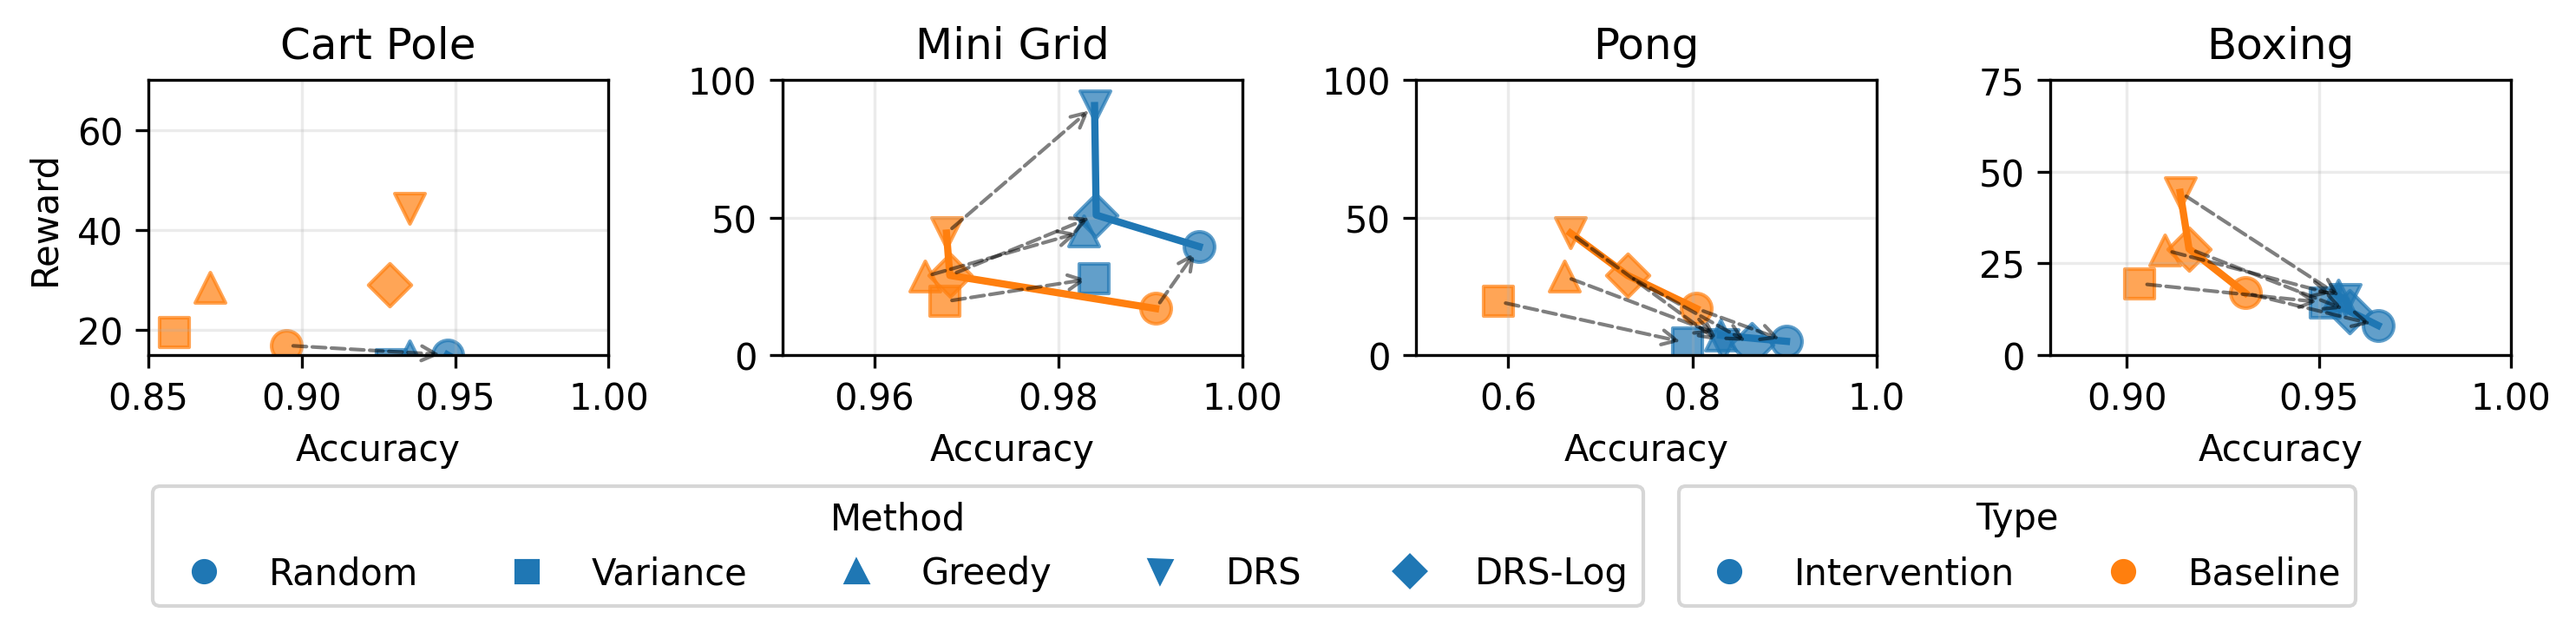

In [61]:
def pareto_front(points):
    pts = points[points[:, 0].argsort()[::-1]]
    front = [pts[0]]
    for p in pts[1:]:
        if p[1] >= front[-1][1]:
            front.append(p)
    return np.array(front)


def plot_env(ax, baseline, intervention, title, xlim, ylim):
    markers = ['o', 's', '^', 'v', 'D']

    for i, (x, y) in enumerate(intervention):
        ax.scatter(x, y, marker=markers[i], s=70, color='C0', alpha=0.7)
    for i, (x, y) in enumerate(baseline):
        ax.scatter(x, y, marker=markers[i], s=70, color='C1', alpha=0.7)

    ax.plot(*pareto_front(intervention).T, lw=2)
    ax.plot(*pareto_front(baseline).T, lw=2)

    for b, i in zip(baseline, intervention):
        ax.annotate("", xy=i, xytext=b,
                    arrowprops=dict(arrowstyle="->", ls="--", lw=1, alpha=0.5))

    ax.set_title(title)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel("Accuracy")
    if title == "Cart Pole":
        ax.set_ylabel("Reward")
    ax.grid(alpha=0.25)


# ------------------------
# Figure
# ------------------------
fig, axes = plt.subplots(1, 4, figsize=(10, 2))

PLOT_CONFIG = {
    "cart_pole": ([0.85, 1.0], [15, 70]),
    "mini_grid": ([0.95, 1.0], [0, 100]),
    "pong":      ([0.5, 1.0],  [0, 100]),
    "boxing":    ([0.88, 1.0], [0, 75]),
}

for ax, env in zip(axes, ["cart_pole", "mini_grid", "pong", "boxing"]):
    baseline, intervention = results[env]
    plot_env(ax, baseline, intervention, env.replace("_", " ").title(),
             *PLOT_CONFIG[env])

# ------------------------
# Legends
# ------------------------
color_handles = [
    mlines.Line2D([], [], color='C0', marker='o', linestyle='None', label='Intervention'),
    mlines.Line2D([], [], color='C1', marker='o', linestyle='None', label='Baseline')
]

method_names = ['Random', 'Variance', 'Greedy', 'DRS', 'DRS-Log']
markers = ['o', 's', '^', 'v', 'D']
method_handles = [
    mlines.Line2D([], [], color='C0', marker=markers[i], linestyle='None',
                  label=method_names[i])
    for i in range(len(method_names))
]

fig.legend(handles=color_handles, loc="upper center", ncol=2, title="Type",bbox_to_anchor=(0.78,0.075))
fig.legend(handles=method_handles, loc="upper center", ncol=5, title="Method",bbox_to_anchor=(0.35,0.075))

plt.tight_layout()
plt.savefig("../../results/figures/intervention_comparison.pdf", dpi=300,bbox_inches='tight')
plt.show()


In [63]:
gold_timesteps = [100000,250000,500000]
methods = ["entropy","greedy","lp_hybrid","multiple_log"]
e = "mini_grid"

performance_by_gold = []
gold_std = []
for m in methods:
    temp = []
    temp_std = []
    for g in gold_timesteps:
        matching_params = get_results_matching_parameters("ablations","",{'environment_string': e,'gold_timesteps':g,
                                                                  'method': m, 'training_timesteps': 500_000})
        if len(matching_params) > 0:
            val = method_scales[1](np.mean([i[m]['reward'] for i in matching_params]))
        else:
            val = 0
        print(m,g,len(matching_params))
        temp.append(val)
        temp_std.append(method_scales_std[1](np.std([i[m]['reward'] for i in matching_params]))/len(matching_params)**.5)
    performance_by_gold.append(temp)
    gold_std.append(temp_std)
np.array(performance_by_gold)

entropy 100000 6
entropy 250000 6
entropy 500000 6
greedy 100000 6
greedy 250000 6
greedy 500000 6
lp_hybrid 100000 6
lp_hybrid 250000 6
lp_hybrid 500000 6
multiple_log 100000 6
multiple_log 250000 6
multiple_log 500000 6


array([[68.29421637, 64.30251172, 60.24189061],
       [50.66495201, 65.61391056, 78.61800143],
       [96.26671663, 96.22590805, 96.22732159],
       [42.59363336, 70.39455553, 94.83280832]])

In [64]:
performance_by_gold

[[68.2942163715676, 64.30251172112719, 60.24189060746969],
 [50.6649520149695, 65.61391056495029, 78.61800143010686],
 [96.26671663144609, 96.22590804777289, 96.2273215916739],
 [42.59363336246582, 70.39455553038499, 94.83280832198263]]

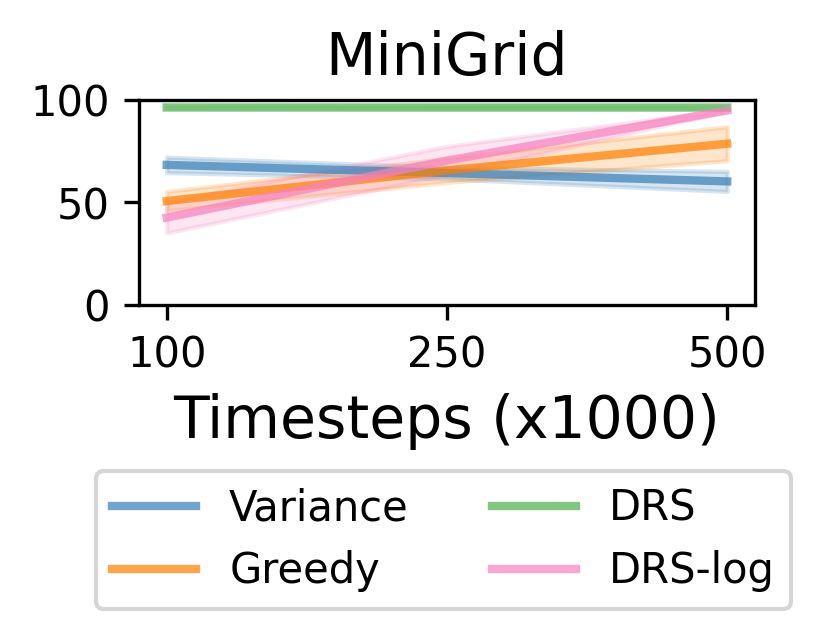

In [65]:
# Plot #concpet perf. 
# Plot Comparison for each env
plot_dimensions = (1,1)
titles = [["MiniGrid"]]

sup_y_label = ""
overall_format = {'figsize':(3,2),
    'style_size': style_size,
    'has_grid': False, 
    'x_ticks': [[[list(range(len(gold_timesteps))),[str(g//1000) for g in gold_timesteps]] for i in range(5)] for j in range(1)],
    'y_lim': [[[0,100]]]
}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles,x_labels=[["Timesteps (x1000)"]])

line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()

x_groups = [list(range(3)) for j in range(4)]
y_vals = np.array(performance_by_gold)
y_std = gold_std
plot_line(ax[0][0],x_groups,y_vals,y_std,["Variance","Greedy","DRS","DRS-log"],line_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 2, 'bbox_to_anchor': (0.15,-0.15),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/gold_timesteps.pdf",dpi=300, bbox_inches='tight')

In [78]:
two_stage = []
basic_comparison = []
perfect_environments = ['cart_pole',"mini_grid"]
perfect_methods = ["mi","relaxed","rho_0","rho_05","rho_075","lp_hybrid"]

imperfect_environments = ['cart_pole',"mini_grid"]
imperfect_methods =  ["mi","relaxed","rho_0","rho_05","rho_075","lp_hybrid"]

num_concepts_selected = {
    'cart_pole': 3,
    'mini_grid': 11, 
    'pong': 57,
    'boxing': 48,
    'glucose': 10
}

gold_timesteps = {
    'cart_pole': 4_000_000,
    'mini_grid': 1_000_000,
    'glucose': 4_000_000,
    'pong': 15_000_000,
    'boxing': 30_000_000,
}


all_performances_perfect_lp = []
all_performances_imperfect_lp = []

all_baselines = []

for j,e in enumerate(perfect_environments):
    temp = []
    for m in perfect_methods:
        matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                    'num_concepts_selected': num_concepts_selected[e],'experiment': 'perfect_comparison',
                                                                    'method': m, 'gold_timesteps': gold_timesteps[e]})
        print("Perfect",e,m,len(matching_params),[(i[m]['reward'],i['parameters']['seed'],i[m]['concepts']) for i in matching_params if m in i])

        performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
        temp.append(performance)
    all_performances_perfect_lp.append(temp)

for j,e in enumerate(imperfect_environments):
    temp = []
    for m in imperfect_methods:
        matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],
                                                                    'num_concepts_selected': num_concepts_selected[e],'experiment': 'imperfect_comparison',
                                                                    'method': m, 'gold_timesteps': gold_timesteps[e]})
        
        print("Imperfect",e,m,len(matching_params),[(i[m]['reward'],i['parameters']['seed'],i[m]['concepts']) for i in matching_params if m in i])
        performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
        temp.append(performance)

    all_performances_imperfect_lp.append(temp)

for j,e in enumerate(imperfect_environments):
    matching_params = get_results_matching_parameters("basic","",{'environment_string': e,'training_timesteps':training_times[e],'gold_timesteps': gold_timesteps[e],
                                                                'num_concepts_selected': num_concepts_selected[e],'experiment': 'imperfect_comparison', 'method': 'ground_truth'})
    m = 'ground_truth'
    print("Imperfect",e,m,len(matching_params),[(i[m]['reward'],i['parameters']['seed']) for i in matching_params if m in i])
    performance = method_scales[j](np.mean([i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]))
    all_baselines.append(performance)
all_baselines.append(0)

Perfect cart_pole mi 6 [(246.3084577114428, 43, [10, 9, 2]), (269.31436314363145, 42, [10, 6, 3]), (118.65393794749403, 45, [3, 10, 1]), (164.46688741721854, 44, [9, 8, 10]), (129.09362808842653, 47, [1, 9, 3]), (100.58198380566802, 46, [0, 1, 9])]
Perfect cart_pole relaxed 6 [(197.99600798403193, 46, [1, 4, 7]), (417.0425531914894, 47, [1, 7, 10]), (406.19166666666666, 45, [1, 7, 10]), (410.9916666666667, 43, [1, 7, 10]), (204.00821355236138, 42, [1, 4, 7]), (413.1386554621849, 44, [1, 7, 10])]
Perfect cart_pole rho_0 6 [(457.16355140186914, 47, [4, 7, 10]), (417.017094017094, 43, [3, 7, 10]), (454.78139534883724, 46, [4, 7, 10]), (457.3488372093023, 44, [4, 7, 10]), (455.2083333333333, 42, [4, 7, 10]), (448.3761467889908, 45, [4, 7, 10])]
Perfect cart_pole rho_05 6 [(457.3488372093023, 44, [4, 7, 10]), (417.017094017094, 43, [3, 7, 10]), (455.2083333333333, 42, [4, 7, 10]), (457.16355140186914, 47, [4, 7, 10]), (448.3761467889908, 45, [4, 7, 10]), (454.78139534883724, 46, [4, 7, 10])

Perfect mini_grid relaxed 6 [(0.9554276794881729, 45, [0, 5, 7, 10, 11, 12, 19, 20, 30, 34, 38]), (0.9607284726716108, 46, [2, 5, 7, 10, 11, 12, 14, 19, 29, 34, 38]), (0.9608359811225575, 42, [2, 5, 10, 11, 12, 19, 21, 30, 34, 38, 42]), (0.960360333354663, 44, [0, 5, 6, 10, 11, 12, 14, 30, 34, 39, 43]), (0.9609497141975215, 43, [2, 5, 10, 11, 12, 19, 20, 21, 29, 37, 38]), (0.960875132260672, 47, [0, 5, 10, 11, 12, 19, 20, 21, 29, 36, 38])]
Perfect mini_grid rho_0 6 [(0.9609497141975215, 43, [2, 5, 10, 11, 12, 19, 20, 21, 29, 37, 38]), (0.9607190601121177, 45, [2, 6, 7, 10, 11, 12, 14, 20, 29, 34, 38]), (0.9420197558687029, 44, [2, 5, 7, 10, 11, 19, 21, 30, 37, 39, 43]), (0.961402023655655, 47, [2, 7, 10, 11, 12, 19, 21, 29, 36, 39, 42]), (0.9605911811793315, 46, [2, 5, 7, 10, 11, 12, 14, 20, 29, 34, 38]), (0.9608686314904865, 42, [2, 6, 7, 10, 11, 12, 14, 19, 30, 34, 38])]
Perfect mini_grid rho_05 6 [(0.9608763582203276, 42, [2, 7, 10, 11, 12, 19, 21, 30, 34, 38, 42]), (0.9554276794881

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


6 six_color 1
6 six_color 1
6 six_color 1
6 six_color 1


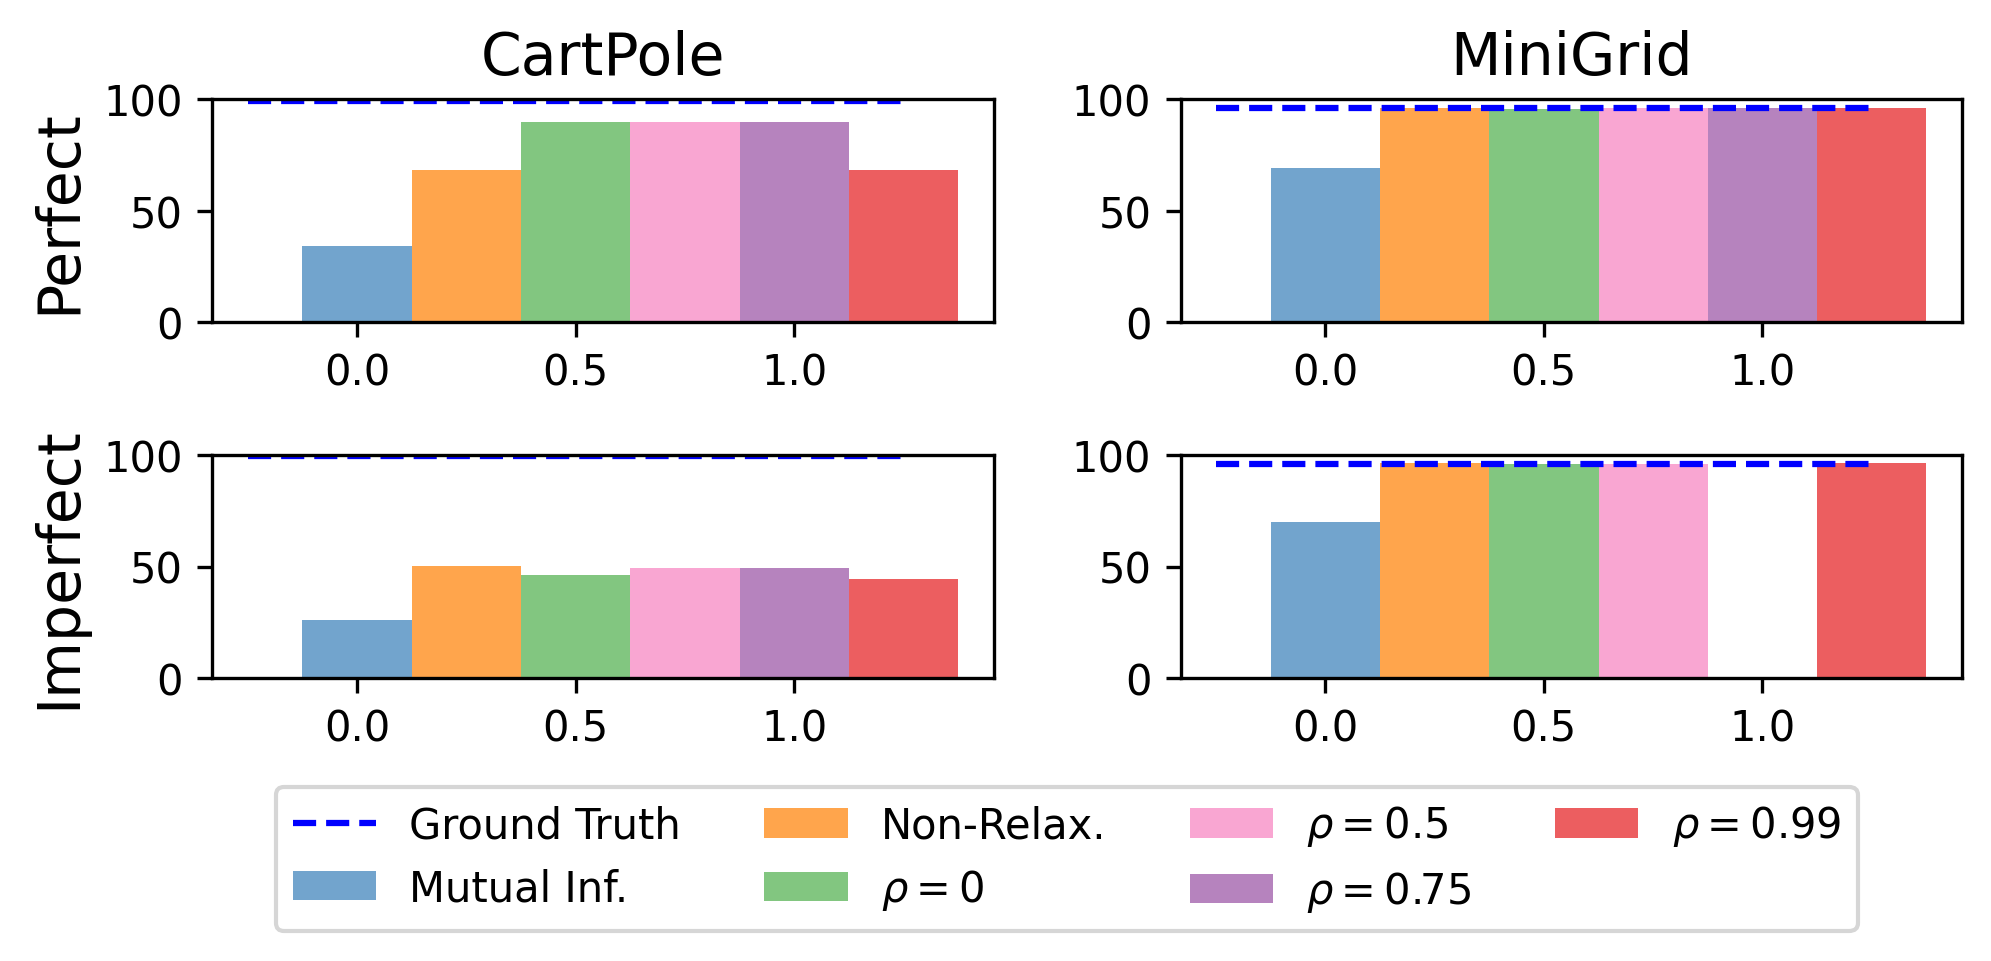

In [105]:
plot_dimensions = (2,len(perfect_environments))

titles = [[name_to_nice[i] for i in perfect_environments],["" for i in range(2)]]

sup_y_label = ""
overall_format = {'figsize':(7,3),
    'style_size': style_size,
    'has_grid': False, 
    'y_lim': [[[0,100] for i in range(5)] for i in range(2)]

}

fig,ax = create_axes(plot_dimensions,overall_format,titles=titles,y_labels=[["Perfect",""],["Imperfect",""]])

bar_format = {'color_palette': 'six_color', 'linewidth': 10, 'style_size': style_size,
}
plt.tight_layout()

for i in range(len(perfect_environments)):
    x_groups = list(range(len(all_performances_perfect_lp[i])))
    y_vals = all_performances_perfect_lp[i]

    plot_bar(ax[0][i],x_groups,y_vals,[0 for i in range(len(y_vals))], {
        0: 'Mutual Inf.',
        1: 'Non-Relax.',
        2: '$\\rho=0$',
        3: '$\\rho=0.5$',
        4: '$\\rho=0.75$',
        5: '$\\rho=0.99$'
    },bar_format)
        
    ax[0][i].hlines(all_baselines[i],-0.25,1.25,label="Ground Truth",color="blue",linestyle="--")


for i in range(len(imperfect_environments)):
    x_groups = list(range(len(all_performances_imperfect_lp[i])))
    y_vals = all_performances_imperfect_lp[i]

    plot_bar(ax[1][i],x_groups,y_vals,[0 for i in range(len(y_vals))],  {
        0: 'Mutual Inf.',
        1: 'Non-Relax.',
        2: '$\\rho=0$',
        3: '$\\rho=0.5$',
        4: '$\\rho=0.75$',
        5: '$\\rho=0.99$',
    },bar_format)
    
    ax[1][i].hlines(all_baselines[i],-0.25,1.25,label="Ground Truth",color="blue",linestyle="--")


legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 4, 'bbox_to_anchor': (0.15,-0.125),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/perfect_other_methods.pdf",dpi=300, bbox_inches='tight')

In [107]:
import numpy as np

# -------------------------
# Load + filter experiments
# -------------------------
matching_params = get_results_matching_parameters(
    "cub", "", {"num_concepts_selected": 311}
)
matching_params = [
    m for m in matching_params if "epochs" not in m["parameters"]
]

C_VALUES = list(range(20, 311, 20))
INTERVENTIONS = [0.2, 0.4, 0.6, 0.8, 1.0]
N = len(matching_params)

# -------------------------
# Method registry
# -------------------------
METHODS = {
    "random": "Random",
    "entropy": "Variance",
    "greedy": "Greedy",
    "lp": "DRS",
    "multiple": "DRS-Log",
}

# -------------------------
# Helpers (mean + stderr)
# -------------------------
def mean_stderr_curve(params, path, xs):
    vals = np.array([
        [m[path.split("/")[0]][path.split("/")[1]][str(x)]["reward"] for x in xs]
        for m in params
    ])
    return vals.mean(axis=0), vals.std(axis=0) / np.sqrt(len(vals))


def mean_stderr_similarity(params, path, ref_path, xs):
    vals = np.array([
        [
            len(
                set(m[path.split("/")[0]][path.split("/")[1]][str(x)]["concepts"])
                & set(m[ref_path.split("/")[0]][ref_path.split("/")[1]]["concepts"])
            ) / x
            for x in xs
        ]
        for m in params
    ])
    return vals.mean(axis=0), vals.std(axis=0) / np.sqrt(len(vals))


# -------------------------
# Rewards (no intervention)
# -------------------------
rewards, rewards_stderr = {}, {}
for k, p in {
    "random": "imperfect/random",
    "greedy": "imperfect/greedy",
    "entropy": "imperfect/entropy",
    "lp": "imperfect/lp_hybrid",
    "multiple": "imperfect/multiple_log",
}.items():
    rewards[k], rewards_stderr[k] = mean_stderr_curve(
        matching_params, p, C_VALUES
    )

manual_reward = np.mean(
    [m["imperfect"]["manual"]["reward"] for m in matching_params]
)

# -------------------------
# Similarities
# -------------------------
similarities, similarities_stderr = {}, {}
for k, p in {
    "random": "imperfect/random",
    "greedy": "imperfect/greedy",
    "entropy": "imperfect/entropy",
    "lp": "imperfect/lp_hybrid",
    "multiple": "imperfect/multiple_log",
}.items():
    similarities[k], similarities_stderr[k] = mean_stderr_similarity(
        matching_params, p, "imperfect/manual", C_VALUES
    )

# -------------------------
# Intervention curves
# -------------------------
intervention_rewards, intervention_stderr = {}, {}
for k, p in {
    "random": "intervention/random",
    "greedy": "intervention/greedy",
    "entropy": "intervention/entropy",
    "lp": "intervention/lp_hybrid",
    "multiple": "intervention/multiple_log",
    "manual": "intervention/manual",
}.items():
    intervention_rewards[k], intervention_stderr[k] = mean_stderr_curve(
        matching_params, p, INTERVENTIONS
    )


In [108]:
manual_reward

0.615493038775745

In [109]:
rewards

{'random': array([0.1613163 , 0.39376942, 0.4857036 , 0.55908411, 0.57565297,
        0.5900932 , 0.59826257, 0.60709355, 0.60798527, 0.60700725,
        0.61068922, 0.61382465, 0.61624094, 0.61929007, 0.61995167]),
 'greedy': array([0.32645841, 0.51958923, 0.58603728, 0.60395812, 0.61227132,
        0.61595329, 0.61969279, 0.62032562, 0.61903118, 0.61811069,
        0.62075711, 0.61992291, 0.62044069, 0.62038315, 0.62055575]),
 'entropy': array([0.5360718 , 0.59086987, 0.60671959, 0.61439995, 0.614026  ,
        0.61629847, 0.61762168, 0.62029686, 0.62026809, 0.62058451,
        0.6200092 , 0.62058451, 0.62041192, 0.62107352, 0.62021056]),
 'lp': array([0.5353239 , 0.59179036, 0.60715108, 0.61255897, 0.61356576,
        0.6162697 , 0.61790933, 0.61828328, 0.61980785, 0.62055575,
        0.6201818 , 0.61977908, 0.6200092 , 0.62061328, 0.6193476 ]),
 'multiple': array([0.53474859, 0.59133011, 0.60651824, 0.61204119, 0.61301922,
        0.61670119, 0.61779427, 0.61931884, 0.62032562, 0.6

In [110]:
intervention_rewards['lp'][2]/intervention_rewards['manual'][2]

0.9990897444541837

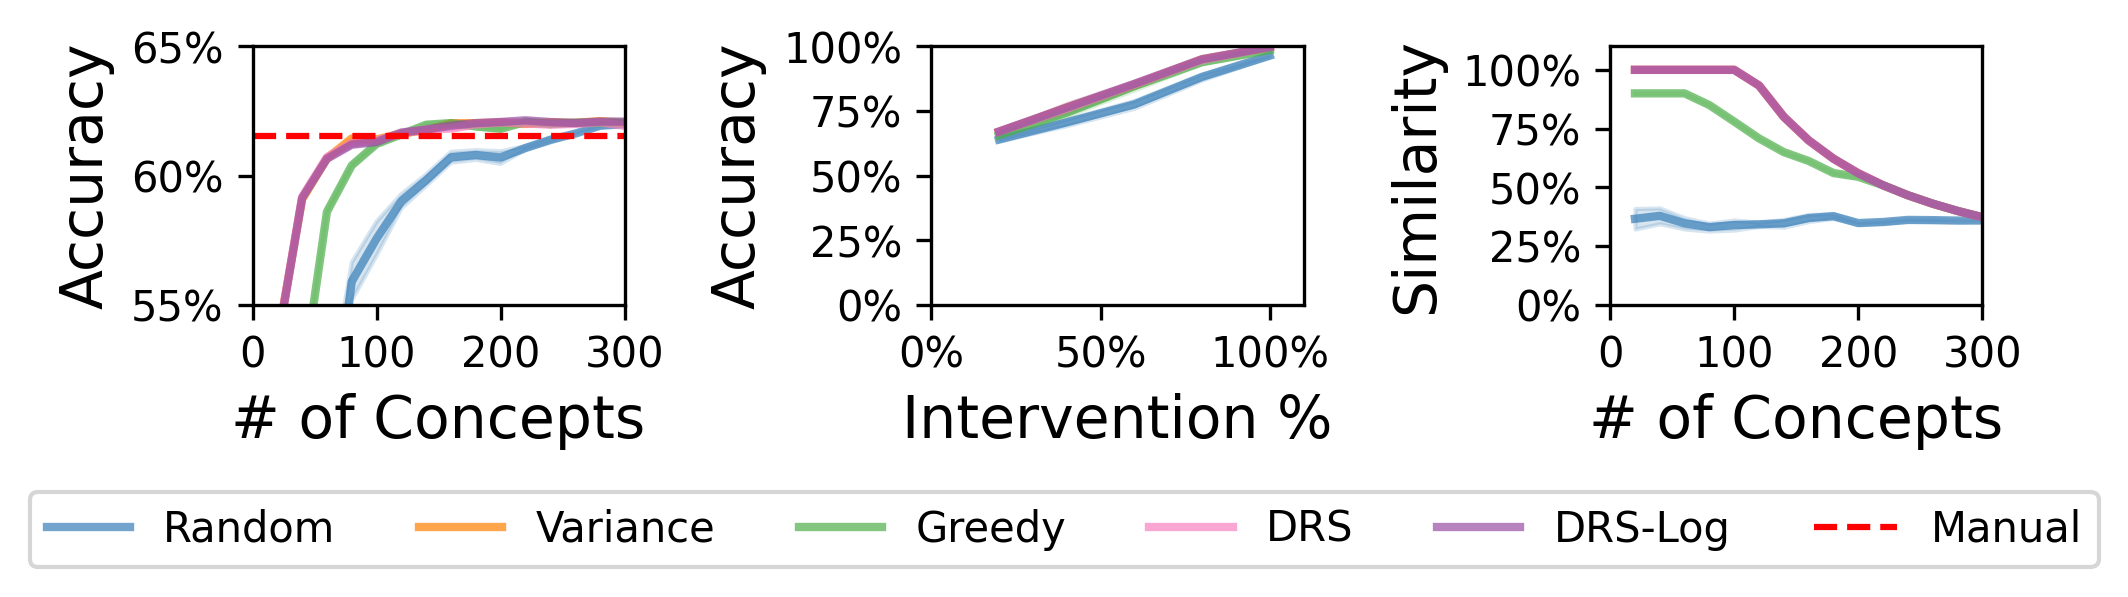

In [111]:
# -------------------------
# Figure setup
# -------------------------
plot_dimensions = (1, 3)
METHODS["manual"] = "Manual"

overall_format = {
    "figsize": (7, 2),
    "style_size": style_size,
    "has_grid": False,
    "x_lim": [[[20, 300], [0, 1.1], [20, 300]]],
    "y_lim": [[[0.55, 0.65], [0, 1], [0, 1.1]]],
    "y_ticks": [[
        [[0.55, 0.6, 0.65], ["55%", "60%", "65%"]],
        [[0, 0.25, 0.5, 0.75, 1], ["0%", "25%", "50%", "75%", "100%"]],
        [[0, 0.25, 0.5, 0.75, 1], ["0%", "25%", "50%", "75%", "100%"]],
    ]],
    "x_ticks": [[
        [[0,100,200,300], [0,100,200,300]],
        [[0,0.5,1], ["0%", "50%", "100%"]],
        [[0,100,200,300], [0,100,200,300]],
    ]],

}

fig, ax = create_axes(
    plot_dimensions,
    overall_format,
    x_labels=[["# of Concepts", "Intervention %", "# of Concepts"]],
    y_labels=[["Accuracy", "Accuracy", "Similarity"]],
)

line_format = {"color_palette": "six_color", "linewidth": 2}

# -------------------------
# Panel 1: reward vs #concepts
# -------------------------
methods_panel1 = ["random", "entropy", "greedy", "lp", "multiple"]
labels_panel1 = [METHODS[m] for m in methods_panel1]

plot_line(
    ax[0][0],
    [C_VALUES] * len(methods_panel1),
    [rewards[m] for m in methods_panel1],
    [rewards_stderr[m] for m in methods_panel1],
    labels_panel1,
    line_format,
)

ax[0][0].hlines(
    manual_reward, 0, 311, label="Manual", color="red", linestyle="--"
)

# -------------------------
# Panel 2: intervention
# -------------------------
methods_panel2 = ["random", "entropy", "greedy", "lp", "multiple"]
labels_panel2 = [METHODS[m] for m in methods_panel2]

plot_line(
    ax[0][1],
    [INTERVENTIONS] * len(methods_panel2),
    [intervention_rewards[m] for m in methods_panel2],
    [intervention_stderr[m] for m in methods_panel2],
    labels_panel2,
    line_format,
)

# -------------------------
# Panel 3: similarity
# -------------------------
plot_line(
    ax[0][2],
    [C_VALUES] * len(methods_panel1),
    [similarities[m] for m in methods_panel1],
    [similarities_stderr[m] for m in methods_panel1],
    labels_panel1,
    line_format,
)

# -------------------------
# Legend + save
# -------------------------
legend_format = {
    "style_size": style_size,
    "type": "is_global",
    "loc": "lower left",
    "ncol": 6,
    "bbox_to_anchor": (0.02, -0.08),
    "fontsize": 10,
}

create_legend(fig, ax, plot_dimensions, legend_format)
plt.tight_layout()
fig.savefig(
    "../../results/figures/imperfect_cub.pdf",
    dpi=300,
    bbox_inches="tight",
)
